# 1. Libraries


In [85]:
import pandas as pd
import numpy as np
import glob
import os
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
import os
import seaborn as sns

sns.set_style("whitegrid")

# 2. Data Path and Loading

In [86]:
DATA_DIR = Path("../data/eye_tracking")

In [87]:
participant_id = "001"

In [88]:
dfs = []

for condition in [1, 2, 3]:
    matches = list(DATA_DIR.glob(f"{participant_id}_ET_Data_Condition{condition}_*.csv"))

    if not matches:
        raise FileNotFoundError(
            f"No file found for participant {participant_id}, condition {condition}"
        )

    file_path = matches[0]

    df_condition = pd.read_csv(file_path, low_memory=False)
    df_condition["participant_id"] = participant_id
    df_condition["condition_number"] = condition

    dfs.append(df_condition)

df = pd.concat(dfs, ignore_index=True)
df.head()


,gaze_capture_time,raw_timestamp,relative_to_unix_epoch_timestamp,focus_distance,frame_number,stability,status,gaze_forward_x,gaze_forward_y,gaze_forward_z,...,trial_number,model_visibility_state,object_position_x,object_position_y,object_position_z,object_rotation_x,object_rotation_y,object_rotation_z,object_rotation_w,participant_id
0,1000001481958514100,1778060264384,592.3813,2.0,232023,0.0,Valid,-0.097741,0.230809,0.968077,...,0,0,3.25,1.52,-0.11,0.0,-0.707107,0.0,0.707107,001
1,1000001481963514900,1778060264384,592.3813,2.0,232024,0.0,Valid,-0.097410,0.230441,0.968198,...,0,0,3.25,1.52,-0.11,0.0,-0.707107,0.0,0.707107,001
2,1000001481968515700,1778060264384,592.3813,2.0,232025,0.0,Valid,-0.097012,0.229992,0.968345,...,0,0,3.25,1.52,-0.11,0.0,-0.707107,0.0,0.707107,001
3,1000001481973516500,1778060264384,592.3813,2.0,232026,0.0,Valid,-0.096599,0.229737,0.968447,...,0,0,3.25,1.52,-0.11,0.0,-0.707107,0.0,0.707107,001
4,1000001481978516800,1778060264384,592.3813,2.0,232027,0.0,Valid,-0.096269,0.230169,0.968377,...,0,0,3.25,1.52,-0.11,0.0,-0.707107,0.0,0.707107,001


In [89]:
def cleaning_function(df: pd.DataFrame) -> pd.DataFrame:
    """
    Preprocess eye-tracking data for analysis.

    Steps:

       - remove training models (TM) and NaN
 ......
    """

    df = df.copy()

    mask = (
        df["model_name"].notna() &
        (~df["model_name"].str.contains("TM", na=False))
    )
    df = df.loc[mask].copy()


    return df

In [90]:
df = cleaning_function(df)

In [91]:
def add_time_per_trial(df, time_col="gaze_capture_time"):
    df = df.copy()

    df = df.sort_values(["condition_number", "trial_number", time_col])

    trial_start = df.groupby(["condition_number", "trial_number"])[time_col].transform("min")

    df["time_ms"] = (df[time_col] - trial_start) / 1_000_000

    return df

In [92]:
df = add_time_per_trial(df, time_col="gaze_capture_time")

In [93]:
df

,gaze_capture_time,raw_timestamp,relative_to_unix_epoch_timestamp,focus_distance,frame_number,stability,status,gaze_forward_x,gaze_forward_y,gaze_forward_z,...,model_visibility_state,object_position_x,object_position_y,object_position_z,object_rotation_x,object_rotation_y,object_rotation_z,object_rotation_w,participant_id,time_ms
26092,1000001886734534500,1778060668925,996.9191,2.000000,312947,0.683982,Valid,0.031344,0.294718,0.955070,...,0,3.25,1.520,-0.11,0.0,-0.707107,0.0,0.707107,001,0.0000
26093,1000001886739535200,1778060668925,996.9191,2.000000,312948,0.682689,Valid,0.031658,0.294867,0.955014,...,0,3.25,1.520,-0.11,0.0,-0.707107,0.0,0.707107,001,5.0007
26094,1000001886744543200,1778060668934,996.9284,2.000000,312949,0.749988,Valid,0.031943,0.294998,0.954964,...,0,3.25,1.520,-0.11,0.0,-0.707107,0.0,0.707107,001,10.0087
26095,1000001886749543300,1778060668934,996.9284,2.000000,312950,0.851914,Valid,0.032383,0.294995,0.954950,...,0,3.25,1.520,-0.11,0.0,-0.707107,0.0,0.707107,001,15.0088
26096,1000001886754542400,1778060668945,996.9396,2.000000,312951,1.000000,Valid,0.032786,0.294996,0.954936,...,0,3.25,1.520,-0.11,0.0,-0.707107,0.0,0.707107,001,20.0079
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
549143,1000005088780099400,1778063870984,3723.7470,0.583587,953108,0.912354,Valid,0.229579,-0.162637,0.959606,...,0,0.75,0.975,-0.70,0.0,0.000000,0.0,1.000000,001,23348.9986
549144,1000005088785100000,1778063870984,3723.7470,0.583548,953109,0.906667,Valid,0.229546,-0.162617,0.959617,...,0,0.75,0.975,-0.70,0.0,0.000000,0.0,1.000000,001,23353.9992
549145,1000005088790100900,1778063870984,3723.7470,0.583413,953110,0.888851,Valid,0.229516,-0.162539,0.959637,...,0,0.75,0.975,-0.70,0.0,0.000000,0.0,1.000000,001,23359.0001
549146,1000005088795101500,1778063870984,3723.7470,0.583175,953111,0.873793,Valid,0.229448,-0.162440,0.959670,...,0,0.75,0.975,-0.70,0.0,0.000000,0.0,1.000000,001,23364.0007


In [94]:
FORWARD_COLS = ["gaze_forward_x", "gaze_forward_y", "gaze_forward_z"]
CLEAN_FORWARD_COLS = ["clean_gaze_forward_x", "clean_gaze_forward_y", "clean_gaze_forward_z"]


def good_status(left_status: pd.Series, right_status: pd.Series) -> np.ndarray:
    l = left_status.astype(str).str.lower().str.strip()
    r = right_status.astype(str).str.lower().str.strip()

    allowed_pairs = {
        ("tracked", "tracked"),
        ("tracked", "compensated"),
        ("compensated", "tracked"),
        ("compensated", "compensated")
    }

    good = pd.Series(
        [(ls, rs) in allowed_pairs for ls, rs in zip(l, r)],
        index=left_status.index
    )

    return good.to_numpy(dtype=bool)

def find_runs(mask: np.ndarray):
    mask = np.asarray(mask, dtype=bool)
    idx = np.flatnonzero(mask)

    if len(idx) == 0:
        return []

    runs = []
    start = prev = idx[0]

    for k in idx[1:]:
        if k == prev + 1:
            prev = k
        else:
            runs.append((start, prev))
            start = prev = k

    runs.append((start, prev))
    return runs

def expand_runs(runs, n, pad=2):
    """
    Expand each run by `pad` samples on both sides,
    then merge overlaps.
    """
    if len(runs) == 0:
        return []

    expanded = []
    for a, b in runs:
        aa = max(0, a - pad)
        bb = min(n - 1, b + pad)
        expanded.append((aa, bb))

    expanded.sort()
    merged = [expanded[0]]

    for a, b in expanded[1:]:
        prev_a, prev_b = merged[-1]
        if a <= prev_b + 1:
            merged[-1] = (prev_a, max(prev_b, b))
        else:
            merged.append((a, b))

    return merged


def normalize_xyz(xyz: np.ndarray) -> np.ndarray:
    xyz = np.asarray(xyz, dtype=float)
    nrm = np.linalg.norm(xyz, axis=1)
    out = np.full_like(xyz, np.nan, dtype=float)
    good = np.isfinite(nrm) & (nrm > 1e-8) & np.all(np.isfinite(xyz), axis=1)
    out[good] = xyz[good] / nrm[good, None]
    return out


def interpolate_segment(sub: pd.DataFrame, forward_cols=FORWARD_COLS, pad: int = 2) -> pd.DataFrame:
    sub = sub.sort_values("time_ms").copy()
    t = sub["time_ms"].to_numpy(dtype=float)

    xyz = np.column_stack([
        pd.to_numeric(sub[c], errors="coerce").to_numpy(dtype=float)
        for c in forward_cols
    ])

    good = good_status(sub["left_status"], sub["right_status"])
    bad = ~good
    bad_runs = find_runs(bad)

    n = len(sub)
    is_interpolated = np.zeros(n, dtype=bool)

    clean = xyz.copy()

    # expand bad runs by buffer
    buffered_runs = expand_runs(bad_runs, n=n, pad=pad)

    # set buffered regions to NaN before interpolation
    for a, b in buffered_runs:
        clean[a:b+1, :] = np.nan

    for a, b in buffered_runs:
        left = a - 1
        right = b + 1

        bracketed = (
            left >= 0 and
            right < n and
            np.all(np.isfinite(xyz[left])) and
            np.all(np.isfinite(xyz[right]))
        )

        if bracketed:
            for dim in range(3):
                clean[a:b+1, dim] = np.interp(
                    t[a:b+1],
                    [t[left], t[right]],
                    [xyz[left, dim], xyz[right, dim]]
                )

            clean[a:b+1, :] = normalize_xyz(clean[a:b+1, :])
            is_interpolated[a:b+1] = True

    sub["good_sample"] = good
    sub["bad_sample"] = bad
    sub["is_interpolated"] = is_interpolated

    for j, c in enumerate(forward_cols):
        sub[f"clean_{c}"] = clean[:, j]

    return sub


def interpolate_all_segments(df: pd.DataFrame, pad: int = 2) -> pd.DataFrame:
    out = []

    for (cond, trial), sub in df.groupby(["condition_number", "trial_number"], sort=True):
        cleaned = interpolate_segment(sub, forward_cols=FORWARD_COLS, pad=pad)
        cleaned["segment_label"] = f"C{int(cond)}_T{int(trial)}"
        out.append(cleaned)

    return (
        pd.concat(out, axis=0)
        .sort_values(["condition_number", "trial_number", "time_ms"])
        .reset_index(drop=True)
    )

In [95]:
df = interpolate_all_segments(df)

In [96]:
def median_filter_valid_runs(x: pd.Series, window: int = 5) -> pd.Series:
    y = x.to_numpy(dtype=float).copy()
    out = y.copy()

    valid = np.isfinite(y)
    idx = np.flatnonzero(valid)

    if len(idx) == 0:
        return pd.Series(out, index=x.index)

    runs = []
    start = prev = idx[0]

    for k in idx[1:]:
        if k == prev + 1:
            prev = k
        else:
            runs.append((start, prev))
            start = prev = k
    runs.append((start, prev))

    for a, b in runs:
        seg = pd.Series(y[a:b+1])

        # centered 5-point median, allowing shorter windows at edges
        filt = seg.rolling(window=window, center=True, min_periods=1).median()

        out[a:b+1] = filt.to_numpy()

    return pd.Series(out, index=x.index)

WINDOW = 5

for col in CLEAN_FORWARD_COLS:
    df[col] = (
        df.groupby(["condition_number", "trial_number"])[col]
        .transform(lambda x: median_filter_valid_runs(x, window=WINDOW))
    )

# renormalize after median filtering
xyz = df[CLEAN_FORWARD_COLS].to_numpy(dtype=float)
df[CLEAN_FORWARD_COLS] = normalize_xyz(xyz)

In [97]:
# 7) QUALITY-CONTROL SUMMARY
qc = (
    df.groupby(["condition_number", "trial_number"])
    .agg(
        n_samples=("time_ms", "size"),
        n_bad=("bad_sample", "sum"),
        n_interpolated=("is_interpolated", "sum"),
    )
    .reset_index()
)

# percentages
qc["pct_bad"] = 100 * qc["n_bad"] / qc["n_samples"]
qc["pct_interpolated"] = 100 * qc["n_interpolated"] / qc["n_samples"]

print(qc.to_string(index=False))

 condition_number  trial_number  n_samples  n_bad  n_interpolated  pct_bad  pct_interpolated
                1             1       6820    232             352 3.401760          5.161290
                1             2       6990    207             296 2.961373          4.234621
                1             3      29675    731            1053 2.463353          3.548441
                1             4      23014    711            1036 3.089424          4.501608
                1             5       8968    417             609 4.649866          6.790812
                1             6      14376    415             545 2.886756          3.791041
                2             1      19533    425             601 2.175805          3.076844
                2             2      42947    943            1247 2.195730          2.903579
                2             3       7649    162             220 2.117924          2.876193
                2             4      22404    521             682 2.32

In [98]:
def add_angular_velocity(df, time_col="gaze_capture_time"):
    """
    Compute gaze angular velocity (deg/s) from Varjo gaze_forward vectors.

    Method
    ------
    1. Take consecutive 3D gaze direction vectors.
    2. Compute the angle between them with:
           angle = atan2(||g_prev x g_curr||, g_prev · g_curr)
       This is numerically stable.
    3. Divide by the time difference in seconds.
    4. Convert from rad/s to deg/s.

    Assumptions
    -----------
    - gaze_forward_x/y/z describe gaze direction.
    - time_col is in nanoseconds.
    - Velocity should be computed within each participant/model block.

    Returns
    -------
    df : copy of input dataframe with a new column:
         - angular_velocity
    """
    df = df.copy()

    # Sort so consecutive rows are truly consecutive in time
    df = df.sort_values(
        ["condition_number", "trial_number", time_col]
    )

    # Initialize output column
    df["angular_velocity"] = np.nan

    # Compute separately within each continuous block
    for (_, _), sub in df.groupby(["condition_number", "trial_number"], sort=False):
        idx = sub.index

        # Extract gaze direction vectors
        g = sub[[
            "clean_gaze_forward_x",
            "clean_gaze_forward_y",
            "clean_gaze_forward_z"
        ]].to_numpy(dtype=float)

        # Normalize vectors just in case they are not perfectly unit length
        norms = np.linalg.norm(g, axis=1, keepdims=True)
        g = g / np.clip(norms, 1e-12, None)

        # Previous and current vectors
        g_prev = g[:-1]
        g_curr = g[1:]

        # Angle between consecutive vectors:
        # angle = atan2(||cross||, dot)
        cross_norm = np.linalg.norm(np.cross(g_prev, g_curr), axis=1)
        dot_prod = np.sum(g_prev * g_curr, axis=1)
        angles_rad = np.arctan2(cross_norm, dot_prod)

        # Time difference in seconds (timestamps are in nanoseconds)
        t = sub[time_col].to_numpy(dtype=np.int64)
        dt = np.diff(t) * 1e-9

        # Prepare output for this block
        vel = np.full(len(sub), np.nan)

        # Only compute where dt is valid
        valid = dt > 0
        vel[1:][valid] = np.degrees(angles_rad[valid] / dt[valid])

        # Write back into dataframe
        df.loc[idx, "angular_velocity"] = vel

    return df

In [99]:
df = add_angular_velocity(df, time_col="gaze_capture_time")

In [100]:
df

,gaze_capture_time,raw_timestamp,relative_to_unix_epoch_timestamp,focus_distance,frame_number,stability,status,gaze_forward_x,gaze_forward_y,gaze_forward_z,...,participant_id,time_ms,good_sample,bad_sample,is_interpolated,clean_gaze_forward_x,clean_gaze_forward_y,clean_gaze_forward_z,segment_label,angular_velocity
0,1000001886734534500,1778060668925,996.9191,2.000000,312947,0.683982,Valid,0.031344,0.294718,0.955070,...,001,0.0000,True,False,False,0.031658,0.294867,0.955014,C1_T1,NaN
1,1000001886739535200,1778060668925,996.9191,2.000000,312948,0.682689,Valid,0.031658,0.294867,0.955014,...,001,5.0007,True,False,False,0.031801,0.294931,0.954989,C1_T1,1.813185
2,1000001886744543200,1778060668934,996.9284,2.000000,312949,0.749988,Valid,0.031943,0.294998,0.954964,...,001,10.0087,True,False,False,0.031943,0.294995,0.954965,C1_T1,1.810543
3,1000001886749543300,1778060668934,996.9284,2.000000,312950,0.851914,Valid,0.032383,0.294995,0.954950,...,001,15.0088,True,False,False,0.032383,0.294996,0.954950,C1_T1,5.043900
4,1000001886754542400,1778060668945,996.9396,2.000000,312951,1.000000,Valid,0.032786,0.294996,0.954936,...,001,20.0079,True,False,False,0.032786,0.294997,0.954935,C1_T1,4.621935
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
354377,1000005088780099400,1778063870984,3723.7470,0.583587,953108,0.912354,Valid,0.229579,-0.162637,0.959606,...,001,23348.9986,True,False,False,0.229580,-0.162612,0.959610,C3_T6,0.596613
354378,1000005088785100000,1778063870984,3723.7470,0.583548,953109,0.906667,Valid,0.229546,-0.162617,0.959617,...,001,23353.9992,True,False,False,0.229546,-0.162611,0.959618,C3_T6,0.395406
354379,1000005088790100900,1778063870984,3723.7470,0.583413,953110,0.888851,Valid,0.229516,-0.162539,0.959637,...,001,23359.0001,True,False,False,0.229516,-0.162539,0.959637,C3_T6,0.926238
354380,1000005088795101500,1778063870984,3723.7470,0.583175,953111,0.873793,Valid,0.229448,-0.162440,0.959670,...,001,23364.0007,True,False,False,0.229482,-0.162489,0.959654,C3_T6,0.712144


In [101]:
def at_mad_threshold(angular_vel, th_0=200.0, min_samples=10, tol=1.0, max_iter=50):
    """
    Compute one adaptive saccade threshold from angular velocity using MAD.

    Parameters
    ----------
    angular_vel : array-like
        Angular velocity values in deg/s.
    th_0 : float, default=200.0
        Initial threshold in deg/s.
    min_samples : int, default=10
        Minimum number of valid samples required.
    tol : float, default=1.0
        Convergence tolerance in deg/s.
    max_iter : int, default=50
        Maximum number of iterations.

    Returns
    -------
    saccade_thresh : float
        Final threshold in deg/s.
    threshs : list[float]
        Threshold values across iterations.
    """
    v = pd.to_numeric(pd.Series(angular_vel), errors="coerce").to_numpy(dtype=float)
    v = v[np.isfinite(v)]

    if len(v) < min_samples:
        return np.nan, []

    threshs = []
    current_th = float(th_0)

    for _ in range(max_iter):
        threshs.append(current_th)

        subset = v[v < current_th]
        subset = subset[np.isfinite(subset)]

        if len(subset) < min_samples:
            return np.nan, threshs

        median = np.median(subset)
        mad = np.median(np.abs(subset - median))
        next_th = median + 3.0 * 1.486 * mad

        if not np.isfinite(next_th):
            return np.nan, threshs

        if abs(current_th - next_th) <= tol:
            threshs.append(float(next_th))
            return float(next_th), threshs

        current_th = float(next_th)

    return float(current_th), threshs


def compute_global_mad_threshold(
    df,
    vel_col="angular_velocity",
    th_0=200.0,
    min_samples=10,
    tol=1.0,
    max_iter=50,
):
    """
    Compute one MAD-based threshold across all trials, conditions, and rows.

    Returns
    -------
    threshold : float
        Global angular velocity threshold.
    summary_df : pd.DataFrame
        One-row summary table for reporting/saving.
    """
    threshold, trace = at_mad_threshold(
        df[vel_col],
        th_0=th_0,
        min_samples=min_samples,
        tol=tol,
        max_iter=max_iter,
    )

    n_valid = pd.to_numeric(df[vel_col], errors="coerce").notna().sum()

    summary_df = pd.DataFrame(
        {
            "mad_threshold": [threshold],
            "n_valid_velocity_samples": [int(n_valid)],
            "threshold_trace": [trace],
        }
    )

    return threshold, summary_df


def add_global_mad_threshold(df, threshold, threshold_col="mad_threshold"):
    """
    Add the same global threshold to every row.
    """
    df = df.copy()
    df[threshold_col] = threshold
    return df


In [102]:
global_threshold, threshold_summary = compute_global_mad_threshold(df)

In [103]:
df = add_global_mad_threshold(df, global_threshold)

In [104]:
print("Global MAD threshold:", global_threshold)

Global MAD threshold: 23.877489944242804


In [105]:
threshold_summary

,mad_threshold,n_valid_velocity_samples,threshold_trace
0,23.87749,354364,"[200.0, 45.60709410209657, 32.39929224493708, ..."


In [106]:
def add_velocity_category(
    df,
    vel_col="angular_velocity",
    threshold_col="mad_threshold",
    category_col="velocity_category",
):
    """
    Label each sample as fixation or saccade using angular velocity and MAD threshold.

    Rules
    -----
    - fixation: angular_velocity < mad_threshold
    - saccade:  angular_velocity >= mad_threshold
    - NaN:      if angular_velocity or mad_threshold is missing
    """
    df = df.copy()

    vel = pd.to_numeric(df[vel_col], errors="coerce")
    thr = pd.to_numeric(df[threshold_col], errors="coerce")

    df[category_col] = pd.Series(pd.NA, index=df.index, dtype="string")

    valid = vel.notna() & thr.notna()
    df.loc[valid & (vel < thr), category_col] = "fixation"
    df.loc[valid & (vel >= thr), category_col] = "saccade"

    return df

In [107]:
df = add_velocity_category(df)

In [108]:
df

,gaze_capture_time,raw_timestamp,relative_to_unix_epoch_timestamp,focus_distance,frame_number,stability,status,gaze_forward_x,gaze_forward_y,gaze_forward_z,...,good_sample,bad_sample,is_interpolated,clean_gaze_forward_x,clean_gaze_forward_y,clean_gaze_forward_z,segment_label,angular_velocity,mad_threshold,velocity_category
0,1000001886734534500,1778060668925,996.9191,2.000000,312947,0.683982,Valid,0.031344,0.294718,0.955070,...,True,False,False,0.031658,0.294867,0.955014,C1_T1,NaN,23.87749,<NA>
1,1000001886739535200,1778060668925,996.9191,2.000000,312948,0.682689,Valid,0.031658,0.294867,0.955014,...,True,False,False,0.031801,0.294931,0.954989,C1_T1,1.813185,23.87749,fixation
2,1000001886744543200,1778060668934,996.9284,2.000000,312949,0.749988,Valid,0.031943,0.294998,0.954964,...,True,False,False,0.031943,0.294995,0.954965,C1_T1,1.810543,23.87749,fixation
3,1000001886749543300,1778060668934,996.9284,2.000000,312950,0.851914,Valid,0.032383,0.294995,0.954950,...,True,False,False,0.032383,0.294996,0.954950,C1_T1,5.043900,23.87749,fixation
4,1000001886754542400,1778060668945,996.9396,2.000000,312951,1.000000,Valid,0.032786,0.294996,0.954936,...,True,False,False,0.032786,0.294997,0.954935,C1_T1,4.621935,23.87749,fixation
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
354377,1000005088780099400,1778063870984,3723.7470,0.583587,953108,0.912354,Valid,0.229579,-0.162637,0.959606,...,True,False,False,0.229580,-0.162612,0.959610,C3_T6,0.596613,23.87749,fixation
354378,1000005088785100000,1778063870984,3723.7470,0.583548,953109,0.906667,Valid,0.229546,-0.162617,0.959617,...,True,False,False,0.229546,-0.162611,0.959618,C3_T6,0.395406,23.87749,fixation
354379,1000005088790100900,1778063870984,3723.7470,0.583413,953110,0.888851,Valid,0.229516,-0.162539,0.959637,...,True,False,False,0.229516,-0.162539,0.959637,C3_T6,0.926238,23.87749,fixation
354380,1000005088795101500,1778063870984,3723.7470,0.583175,953111,0.873793,Valid,0.229448,-0.162440,0.959670,...,True,False,False,0.229482,-0.162489,0.959654,C3_T6,0.712144,23.87749,fixation


In [108]:
df_condition

,gaze_capture_time,raw_timestamp,relative_to_unix_epoch_timestamp,focus_distance,frame_number,stability,status,gaze_forward_x,gaze_forward_y,gaze_forward_z,...,trial_number,model_visibility_state,object_position_x,object_position_y,object_position_z,object_rotation_x,object_rotation_y,object_rotation_z,object_rotation_w,participant_id
0,1000004154588007200,1778062937116,2790.398,0.351046,766342,0.000000,Valid,0.298656,0.159875,0.940874,...,0,0,3.25,1.52,-0.11,0.0,-0.707107,0.0,0.707107,001
1,1000004154888038800,1778062937116,2790.398,0.452291,766402,0.000000,Valid,0.263659,0.158534,0.951500,...,0,0,3.25,1.52,-0.11,0.0,-0.707107,0.0,0.707107,001
2,1000004154893038900,1778062937116,2790.398,0.107576,766403,0.000000,Valid,0.248639,0.160037,0.955284,...,0,0,3.25,1.52,-0.11,0.0,-0.707107,0.0,0.707107,001
3,1000004154898038300,1778062937117,2790.398,0.189546,766404,0.000000,Valid,0.244448,0.160614,0.956268,...,0,0,3.25,1.52,-0.11,0.0,-0.707107,0.0,0.707107,001
4,1000004154903038800,1778062937117,2790.398,0.312154,766405,0.000000,Valid,0.230536,0.161675,0.959538,...,0,0,3.25,1.52,-0.11,0.0,-0.707107,0.0,0.707107,001
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
184438,1000005111509028100,1778063893701,3746.467,1.157945,957652,0.027887,Valid,0.076445,0.145445,0.986409,...,6,0,3.25,1.52,-0.11,0.0,-0.707107,0.0,0.707107,001
184439,1000005111514028600,1778063893701,3746.467,1.148934,957653,0.000000,Valid,0.075853,0.145398,0.986461,...,6,0,3.25,1.52,-0.11,0.0,-0.707107,0.0,0.707107,001
184440,1000005111519029800,1778063893711,3746.478,1.150903,957654,0.000000,Valid,0.075171,0.145675,0.986472,...,6,0,3.25,1.52,-0.11,0.0,-0.707107,0.0,0.707107,001
184441,1000005111524031000,1778063893711,3746.478,1.141437,957655,0.000000,Valid,0.074669,0.146021,0.986460,...,6,0,3.25,1.52,-0.11,0.0,-0.707107,0.0,0.707107,001


In [109]:
def add_saccade_fixation_ids(
    df,
    group_cols=("condition_number", "trial_number"),
    category_col="velocity_category",
    time_col="time_ms",
):
    """
    Add separate IDs for consecutive saccade and fixation runs.

    Output columns:
    - saccade_id
    - fixation_id
    - event_duration_ms

    Duration is computed as:
    number_of_rows_in_event * median_dt_within_trial
    """
    out = df.copy()
    out = out.sort_values(list(group_cols) + [time_col]).copy()

    out["saccade_id"] = pd.Series(index=out.index, dtype="Int64")
    out["fixation_id"] = pd.Series(index=out.index, dtype="Int64")
    out["event_duration_ms"] = np.nan

    saccade_counter = 0
    fixation_counter = 0

    for _, sub in out.groupby(list(group_cols), sort=False):
        sub = sub.sort_values(time_col)

        labels = sub[category_col].tolist()
        times = pd.to_numeric(sub[time_col], errors="coerce").to_numpy()
        idx = sub.index.to_list()

        # Estimate sampling interval for this trial
        dt = np.diff(times)
        dt = dt[np.isfinite(dt) & (dt > 0)]
        median_dt = float(np.median(dt)) if len(dt) > 0 else np.nan

        run_start = 0

        for i in range(1, len(sub) + 1):
            if i == len(sub):
                run_ended = True
            else:
                curr_label = labels[i]
                start_label = labels[run_start]

                if pd.isna(curr_label) and pd.isna(start_label):
                    run_ended = False
                elif pd.isna(curr_label) or pd.isna(start_label):
                    run_ended = True
                else:
                    run_ended = curr_label != start_label

            if not run_ended:
                continue

            label = labels[run_start]
            run_idx = idx[run_start:i]
            n_rows = len(run_idx)

            if pd.notna(label) and n_rows > 0 and np.isfinite(median_dt):
                duration_ms = n_rows * median_dt
                out.loc[run_idx, "event_duration_ms"] = duration_ms

                if label == "saccade":
                    saccade_counter += 1
                    out.loc[run_idx, "saccade_id"] = saccade_counter

                elif label == "fixation":
                    fixation_counter += 1
                    out.loc[run_idx, "fixation_id"] = fixation_counter

            run_start = i

    return out


In [110]:
df = add_saccade_fixation_ids(df)

In [111]:
df

,gaze_capture_time,raw_timestamp,relative_to_unix_epoch_timestamp,focus_distance,frame_number,stability,status,gaze_forward_x,gaze_forward_y,gaze_forward_z,...,clean_gaze_forward_x,clean_gaze_forward_y,clean_gaze_forward_z,segment_label,angular_velocity,mad_threshold,velocity_category,saccade_id,fixation_id,event_duration_ms
0,1000001886734534500,1778060668925,996.9191,2.000000,312947,0.683982,Valid,0.031344,0.294718,0.955070,...,0.031658,0.294867,0.955014,C1_T1,NaN,23.87749,<NA>,<NA>,<NA>,NaN
1,1000001886739535200,1778060668925,996.9191,2.000000,312948,0.682689,Valid,0.031658,0.294867,0.955014,...,0.031801,0.294931,0.954989,C1_T1,1.813185,23.87749,fixation,<NA>,1,120.0168
2,1000001886744543200,1778060668934,996.9284,2.000000,312949,0.749988,Valid,0.031943,0.294998,0.954964,...,0.031943,0.294995,0.954965,C1_T1,1.810543,23.87749,fixation,<NA>,1,120.0168
3,1000001886749543300,1778060668934,996.9284,2.000000,312950,0.851914,Valid,0.032383,0.294995,0.954950,...,0.032383,0.294996,0.954950,C1_T1,5.043900,23.87749,fixation,<NA>,1,120.0168
4,1000001886754542400,1778060668945,996.9396,2.000000,312951,1.000000,Valid,0.032786,0.294996,0.954936,...,0.032786,0.294997,0.954935,C1_T1,4.621935,23.87749,fixation,<NA>,1,120.0168
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
354377,1000005088780099400,1778063870984,3723.7470,0.583587,953108,0.912354,Valid,0.229579,-0.162637,0.959606,...,0.229580,-0.162612,0.959610,C3_T6,0.596613,23.87749,fixation,<NA>,9947,985.1379
354378,1000005088785100000,1778063870984,3723.7470,0.583548,953109,0.906667,Valid,0.229546,-0.162617,0.959617,...,0.229546,-0.162611,0.959618,C3_T6,0.395406,23.87749,fixation,<NA>,9947,985.1379
354379,1000005088790100900,1778063870984,3723.7470,0.583413,953110,0.888851,Valid,0.229516,-0.162539,0.959637,...,0.229516,-0.162539,0.959637,C3_T6,0.926238,23.87749,fixation,<NA>,9947,985.1379
354380,1000005088795101500,1778063870984,3723.7470,0.583175,953111,0.873793,Valid,0.229448,-0.162440,0.959670,...,0.229482,-0.162489,0.959654,C3_T6,0.712144,23.87749,fixation,<NA>,9947,985.1379


In [112]:
df['hit_obj_name'].value_counts()

hit_obj_name
resource_desk_base     20317
Lego_Board_10x10       15694
work_desk_base         12402
model_desk_base        12372
Wall_Left              10896
                       ...  
stud_top_3_temp_108        1
stud_top_3_temp_086        1
stud_top_5_dis_036         1
stud_top_1_res_123         1
stud_top_3_res_002         1
Name: count, Length: 1369, dtype: int64

In [129]:
df.head()

,gaze_capture_time,raw_timestamp,relative_to_unix_epoch_timestamp,focus_distance,frame_number,stability,status,gaze_forward_x,gaze_forward_y,gaze_forward_z,...,clean_gaze_forward_x,clean_gaze_forward_y,clean_gaze_forward_z,segment_label,angular_velocity,mad_threshold,velocity_category,saccade_id,fixation_id,event_duration_ms
0,1000001965099413200,1778664972473,417.4073,0.694809,307113,0.253343,Valid,0.082935,0.157156,0.984085,...,0.083670,0.155979,0.984210,C1_T0,NaN,29.225413,<NA>,<NA>,<NA>,NaN
1,1000001965104413700,1778664972473,417.4073,0.692337,307114,0.235113,Valid,0.083670,0.155979,0.984210,...,0.084023,0.155376,0.984276,C1_T0,8.045743,29.225413,fixation,<NA>,1,205.0246
2,1000001965109415900,1778664972473,417.4073,0.690582,307115,0.333253,Valid,0.084377,0.154773,0.984340,...,0.084377,0.154773,0.984340,C1_T0,8.043009,29.225413,fixation,<NA>,1,205.0246
3,1000001965114416300,1778664972473,417.4073,0.691362,307116,0.389169,Valid,0.085010,0.153631,0.984465,...,0.085010,0.153631,0.984465,C1_T0,15.027888,29.225413,fixation,<NA>,1,205.0246
4,1000001965119414700,1778664972473,417.4073,0.690736,307117,0.465995,Valid,0.085637,0.152301,0.984617,...,0.085637,0.152301,0.984617,C1_T0,16.943798,29.225413,fixation,<NA>,1,205.0246


In [111]:
def add_fixation_target(
    df,
    fixation_col="fixation_id",
    hit_col="hit_obj_name",
    target_col="fixation_target",
    group_cols=None,
):
    """
    Add fixation_target: the most frequent hit_obj_name within each fixation_id.

    Rows without a fixation_id keep fixation_target as <NA>.
    If there is a tie, the object that appears first within that fixation is used.
    """
    out = df.copy()
    out[target_col] = pd.NA

    if group_cols is None:
        group_cols = [fixation_col]
    elif isinstance(group_cols, str):
        group_cols = [group_cols]
    else:
        group_cols = list(group_cols)

    valid = out[fixation_col].notna()

    def most_frequent_first_seen(s):
        s = s.dropna()
        if s.empty:
            return pd.NA

        counts = s.value_counts(sort=False)
        max_count = counts.max()
        winners = set(counts[counts == max_count].index)

        for value in s:
            if value in winners:
                return value

    out.loc[valid, target_col] = (
        out.loc[valid]
        .groupby(group_cols, sort=False)[hit_col]
        .transform(most_frequent_first_seen)
    )

    return out

In [112]:
df = add_fixation_target(df)

In [115]:
df

,gaze_capture_time,raw_timestamp,relative_to_unix_epoch_timestamp,focus_distance,frame_number,stability,status,gaze_forward_x,gaze_forward_y,gaze_forward_z,...,clean_gaze_forward_y,clean_gaze_forward_z,segment_label,angular_velocity,mad_threshold,velocity_category,saccade_id,fixation_id,event_duration_ms,fixation_target
0,1000001886734534500,1778060668925,996.9191,2.000000,312947,0.683982,Valid,0.031344,0.294718,0.955070,...,0.294867,0.955014,C1_T1,NaN,23.87749,<NA>,<NA>,<NA>,NaN,<NA>
1,1000001886739535200,1778060668925,996.9191,2.000000,312948,0.682689,Valid,0.031658,0.294867,0.955014,...,0.294931,0.954989,C1_T1,1.813185,23.87749,fixation,<NA>,1,120.0168,Wall_Front
2,1000001886744543200,1778060668934,996.9284,2.000000,312949,0.749988,Valid,0.031943,0.294998,0.954964,...,0.294995,0.954965,C1_T1,1.810543,23.87749,fixation,<NA>,1,120.0168,Wall_Front
3,1000001886749543300,1778060668934,996.9284,2.000000,312950,0.851914,Valid,0.032383,0.294995,0.954950,...,0.294996,0.954950,C1_T1,5.043900,23.87749,fixation,<NA>,1,120.0168,Wall_Front
4,1000001886754542400,1778060668945,996.9396,2.000000,312951,1.000000,Valid,0.032786,0.294996,0.954936,...,0.294997,0.954935,C1_T1,4.621935,23.87749,fixation,<NA>,1,120.0168,Wall_Front
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
354377,1000005088780099400,1778063870984,3723.7470,0.583587,953108,0.912354,Valid,0.229579,-0.162637,0.959606,...,-0.162612,0.959610,C3_T6,0.596613,23.87749,fixation,<NA>,9947,985.1379,NextItemButton
354378,1000005088785100000,1778063870984,3723.7470,0.583548,953109,0.906667,Valid,0.229546,-0.162617,0.959617,...,-0.162611,0.959618,C3_T6,0.395406,23.87749,fixation,<NA>,9947,985.1379,NextItemButton
354379,1000005088790100900,1778063870984,3723.7470,0.583413,953110,0.888851,Valid,0.229516,-0.162539,0.959637,...,-0.162539,0.959637,C3_T6,0.926238,23.87749,fixation,<NA>,9947,985.1379,NextItemButton
354380,1000005088795101500,1778063870984,3723.7470,0.583175,953111,0.873793,Valid,0.229448,-0.162440,0.959670,...,-0.162489,0.959654,C3_T6,0.712144,23.87749,fixation,<NA>,9947,985.1379,NextItemButton


In [116]:
(df["fixation_target"].value_counts())

fixation_target
Lego_Board_10x10             10202
model_desk_base               9263
resource_desk_base            9195
Wall_Left                     6997
brick_2x4_yellow_temp_034     4698
                             ...  
stud_top_4_res_007               1
stud_top_3_res_124               1
stud_top_3_res_110               1
stud_top_4_dis_047               1
stud_top_2_temp_077              1
Name: count, Length: 739, dtype: int64

In [115]:
participant_id = "001"
DATA_DIR = Path("../data/body_tracking")

In [116]:
from pathlib import Path
import pandas as pd


def add_body_tracking_data(df, participant_id, DATA_DIR):
    body_dfs = []

    for file_path in sorted(Path(DATA_DIR).glob(f"{participant_id}_BT_Data_Condition*.csv")):
        bt = pd.read_csv(file_path, low_memory=False)
        bt["participant_id"] = participant_id
        body_dfs.append(bt)

    if not body_dfs:
        raise FileNotFoundError(f"No body-tracking files found for participant {participant_id}")

    body = pd.concat(body_dfs, ignore_index=True)

    # Apply the same cleaning logic to body tracking.
    body = cleaning_function(body)

    eye = df.copy()

    eye["participant_id"] = eye["participant_id"].astype(str)
    body["participant_id"] = body["participant_id"].astype(str)

    for data in [eye, body]:
        data["raw_timestamp"] = pd.to_numeric(data["raw_timestamp"], errors="coerce")
        data["relative_to_unix_epoch_timestamp"] = pd.to_numeric(
            data["relative_to_unix_epoch_timestamp"],
            errors="coerce",
        )

    join_cols = [
        col for col in ["participant_id", "condition_number", "trial_number"]
        if col in eye.columns and col in body.columns
    ]

    body_diffs = (
        body.sort_values(join_cols + ["raw_timestamp"])
        .groupby(join_cols, dropna=False)["raw_timestamp"]
        .diff()
        .dropna()
    )
    body_diffs = body_diffs[body_diffs > 0]

    tolerance = int(round(body_diffs.median() * 0.75))

    body = body.rename(
        columns={
            "raw_timestamp": "bt_raw_timestamp",
            "relative_to_unix_epoch_timestamp": "bt_relative_to_unix_epoch_timestamp",
        }
    )

    body_cols = [
        col for col in body.columns
        if col not in join_cols
        and col not in ["bt_raw_timestamp", "bt_relative_to_unix_epoch_timestamp"]
        and not col.startswith("bt_")
    ]

    body = body.rename(columns={col: f"bt_{col}" for col in body_cols})

    eye_sorted = eye.sort_values(join_cols + ["raw_timestamp"]).reset_index(drop=False)
    body_sorted = body.sort_values(join_cols + ["bt_raw_timestamp"])

    joined = pd.merge_asof(
        eye_sorted,
        body_sorted,
        left_on="raw_timestamp",
        right_on="bt_raw_timestamp",
        by=join_cols,
        direction="nearest",
        tolerance=tolerance,
    )

    joined["bt_raw_timestamp_diff_ms"] = (
        joined["raw_timestamp"] - joined["bt_raw_timestamp"]
    ).abs()

    joined["bt_unix_timestamp_diff_ms"] = (
        joined["relative_to_unix_epoch_timestamp"]
        - joined["bt_relative_to_unix_epoch_timestamp"]
    ).abs()

    joined = (
        joined
        .sort_values("index")
        .drop(columns="index")
        .reset_index(drop=True)
    )

    return joined

In [117]:
df = add_body_tracking_data(df, participant_id, DATA_DIR)

In [118]:
df

,gaze_capture_time,raw_timestamp,relative_to_unix_epoch_timestamp,focus_distance,frame_number,stability,status,gaze_forward_x,gaze_forward_y,gaze_forward_z,...,bt_RightGrab_obj_rot_x,bt_RightGrab_obj_rot_y,bt_RightGrab_obj_rot_z,bt_RightGrab_obj_rot_w,bt_model_name,bt_model_rot_deg,bt_LeftFootArea,bt_RightFootArea,bt_raw_timestamp_diff_ms,bt_unix_timestamp_diff_ms
0,1000001886734534500,1778060668925,996.9191,2.000000,312947,0.683982,Valid,0.031344,0.294718,0.955070,...,0.0,0.0,0.0,1.0,C1M5F,0.0,Work,Work,0.0,0.0
1,1000001886739535200,1778060668925,996.9191,2.000000,312948,0.682689,Valid,0.031658,0.294867,0.955014,...,0.0,0.0,0.0,1.0,C1M5F,0.0,Work,Work,0.0,0.0
2,1000001886744543200,1778060668934,996.9284,2.000000,312949,0.749988,Valid,0.031943,0.294998,0.954964,...,0.0,0.0,0.0,1.0,C1M5F,0.0,Work,Work,1.0,0.0
3,1000001886749543300,1778060668934,996.9284,2.000000,312950,0.851914,Valid,0.032383,0.294995,0.954950,...,0.0,0.0,0.0,1.0,C1M5F,0.0,Work,Work,1.0,0.0
4,1000001886754542400,1778060668945,996.9396,2.000000,312951,1.000000,Valid,0.032786,0.294996,0.954936,...,0.0,0.0,0.0,1.0,C1M5F,0.0,Work,Work,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
354377,1000005088780099400,1778063870984,3723.7470,0.583587,953108,0.912354,Valid,0.229579,-0.162637,0.959606,...,0.0,0.0,0.0,1.0,C1M1F,0.0,Work,Work,1.0,0.0
354378,1000005088785100000,1778063870984,3723.7470,0.583548,953109,0.906667,Valid,0.229546,-0.162617,0.959617,...,0.0,0.0,0.0,1.0,C1M1F,0.0,Work,Work,1.0,0.0
354379,1000005088790100900,1778063870984,3723.7470,0.583413,953110,0.888851,Valid,0.229516,-0.162539,0.959637,...,0.0,0.0,0.0,1.0,C1M1F,0.0,Work,Work,1.0,0.0
354380,1000005088795101500,1778063870984,3723.7470,0.583175,953111,0.873793,Valid,0.229448,-0.162440,0.959670,...,0.0,0.0,0.0,1.0,C1M1F,0.0,Work,Work,1.0,0.0


In [119]:
df["bt_raw_timestamp_diff_ms"].value_counts()

bt_raw_timestamp_diff_ms
0.0    283929
1.0     69219
2.0      1049
3.0        87
4.0        56
5.0        17
8.0         3
6.0         1
Name: count, dtype: int64

In [70]:
df["bt_unix_timestamp_diff_ms"].value_counts()

bt_unix_timestamp_diff_ms
0.0    354361
Name: count, dtype: int64

In [120]:
import pandas as pd


def add_grabbed_item_ids(df):
    out = df.copy()

    sort_cols = [
        col for col in [
            "participant_id",
            "condition_number",
            "trial_number",
            "raw_timestamp",
        ]
        if col in out.columns
    ]

    group_cols = [
        col for col in [
            "participant_id",
            "condition_number",
            "trial_number",
        ]
        if col in out.columns
    ]

    out = out.sort_values(sort_cols).reset_index(drop=False)

    for hand in ["LeftHand", "RightHand"]:
        grabbed_col = f"bt_{hand}_grabbed_name"
        grab_id_col = f"{hand.lower()}_grab_id"

        grabbed = out[grabbed_col]

        is_grabbing = grabbed.notna()

        changed_object = grabbed.ne(
            grabbed.groupby([out[col] for col in group_cols]).shift()
        )

        new_grab = is_grabbing & changed_object

        out[grab_id_col] = new_grab.cumsum()
        out.loc[~is_grabbing, grab_id_col] = pd.NA
        out[grab_id_col] = out[grab_id_col].astype("Int64")

    out = (
        out
        .sort_values("index")
        .drop(columns="index")
        .reset_index(drop=True)
    )

    return out

In [121]:
df = add_grabbed_item_ids(df)

In [122]:
df

,gaze_capture_time,raw_timestamp,relative_to_unix_epoch_timestamp,focus_distance,frame_number,stability,status,gaze_forward_x,gaze_forward_y,gaze_forward_z,...,bt_RightGrab_obj_rot_z,bt_RightGrab_obj_rot_w,bt_model_name,bt_model_rot_deg,bt_LeftFootArea,bt_RightFootArea,bt_raw_timestamp_diff_ms,bt_unix_timestamp_diff_ms,lefthand_grab_id,righthand_grab_id
0,1000001886734534500,1778060668925,996.9191,2.000000,312947,0.683982,Valid,0.031344,0.294718,0.955070,...,0.0,1.0,C1M5F,0.0,Work,Work,0.0,0.0,<NA>,<NA>
1,1000001886739535200,1778060668925,996.9191,2.000000,312948,0.682689,Valid,0.031658,0.294867,0.955014,...,0.0,1.0,C1M5F,0.0,Work,Work,0.0,0.0,<NA>,<NA>
2,1000001886744543200,1778060668934,996.9284,2.000000,312949,0.749988,Valid,0.031943,0.294998,0.954964,...,0.0,1.0,C1M5F,0.0,Work,Work,1.0,0.0,<NA>,<NA>
3,1000001886749543300,1778060668934,996.9284,2.000000,312950,0.851914,Valid,0.032383,0.294995,0.954950,...,0.0,1.0,C1M5F,0.0,Work,Work,1.0,0.0,<NA>,<NA>
4,1000001886754542400,1778060668945,996.9396,2.000000,312951,1.000000,Valid,0.032786,0.294996,0.954936,...,0.0,1.0,C1M5F,0.0,Work,Work,0.0,0.0,<NA>,<NA>
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
354377,1000005088780099400,1778063870984,3723.7470,0.583587,953108,0.912354,Valid,0.229579,-0.162637,0.959606,...,0.0,1.0,C1M1F,0.0,Work,Work,1.0,0.0,<NA>,413
354378,1000005088785100000,1778063870984,3723.7470,0.583548,953109,0.906667,Valid,0.229546,-0.162617,0.959617,...,0.0,1.0,C1M1F,0.0,Work,Work,1.0,0.0,<NA>,413
354379,1000005088790100900,1778063870984,3723.7470,0.583413,953110,0.888851,Valid,0.229516,-0.162539,0.959637,...,0.0,1.0,C1M1F,0.0,Work,Work,1.0,0.0,<NA>,413
354380,1000005088795101500,1778063870984,3723.7470,0.583175,953111,0.873793,Valid,0.229448,-0.162440,0.959670,...,0.0,1.0,C1M1F,0.0,Work,Work,1.0,0.0,<NA>,413


In [76]:
df.head()

,gaze_capture_time,raw_timestamp,relative_to_unix_epoch_timestamp,focus_distance,frame_number,stability,status,gaze_forward_x,gaze_forward_y,gaze_forward_z,...,bt_RightGrab_obj_rot_z,bt_RightGrab_obj_rot_w,bt_model_name,bt_model_rot_deg,bt_LeftFootArea,bt_RightFootArea,bt_raw_timestamp_diff_ms,bt_unix_timestamp_diff_ms,lefthand_grab_id,righthand_grab_id
0,1000001886734534500,1778060668925,996.9191,2.0,312947,0.683982,Valid,0.031344,0.294718,0.955070,...,0.0,1.0,C1M5F,0.0,Work,Work,0.0,0.0,<NA>,<NA>
1,1000001886739535200,1778060668925,996.9191,2.0,312948,0.682689,Valid,0.031658,0.294867,0.955014,...,0.0,1.0,C1M5F,0.0,Work,Work,0.0,0.0,<NA>,<NA>
2,1000001886744543200,1778060668934,996.9284,2.0,312949,0.749988,Valid,0.031943,0.294998,0.954964,...,0.0,1.0,C1M5F,0.0,Work,Work,1.0,0.0,<NA>,<NA>
3,1000001886749543300,1778060668934,996.9284,2.0,312950,0.851914,Valid,0.032383,0.294995,0.954950,...,0.0,1.0,C1M5F,0.0,Work,Work,1.0,0.0,<NA>,<NA>
4,1000001886754542400,1778060668945,996.9396,2.0,312951,1.000000,Valid,0.032786,0.294996,0.954936,...,0.0,1.0,C1M5F,0.0,Work,Work,0.0,0.0,<NA>,<NA>


In [123]:
import matplotlib.pyplot as plt

grab_counts = pd.Series({
    "Left hand": df["lefthand_grab_id"].nunique(),
    "Right hand": df["righthand_grab_id"].nunique(),
})

grab_counts

Left hand     220
Right hand    413
dtype: int64

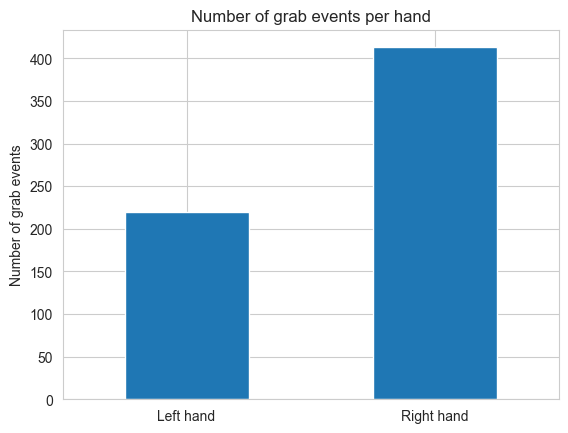

In [124]:
ax = grab_counts.plot(kind="bar")

ax.set_title("Number of grab events per hand")
ax.set_xlabel("")
ax.set_ylabel("Number of grab events")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)

plt.show()

In [125]:
left_brick_grabs = df[
    df["bt_LeftHand_grabbed_name"].astype(str).str.startswith("brick_")
]["lefthand_grab_id"].nunique()

right_brick_grabs = df[
    df["bt_RightHand_grabbed_name"].astype(str).str.startswith("brick_")
]["righthand_grab_id"].nunique()

brick_grab_counts = pd.Series({
    "Left hand": left_brick_grabs,
    "Right hand": right_brick_grabs,
})

brick_grab_counts

Left hand     201
Right hand    307
dtype: int64

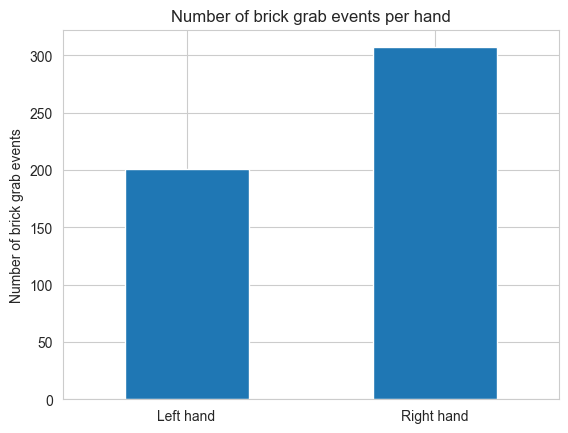

In [126]:
ax = brick_grab_counts.plot(kind="bar")

ax.set_title("Number of brick grab events per hand")
ax.set_xlabel("")
ax.set_ylabel("Number of brick grab events")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)

plt.show()

In [41]:
df_view = df[df["trial_number"] != 0].copy()

In [42]:
df_view

,gaze_capture_time,raw_timestamp,relative_to_unix_epoch_timestamp,focus_distance,frame_number,stability,status,gaze_forward_x,gaze_forward_y,gaze_forward_z,...,bt_RightGrab_obj_rot_x,bt_RightGrab_obj_rot_y,bt_RightGrab_obj_rot_z,bt_RightGrab_obj_rot_w,bt_model_name,bt_model_rot_deg,bt_LeftFootArea,bt_RightFootArea,bt_raw_timestamp_diff,bt_unix_timestamp_diff
13612,1000001821605168400,1778060603954,931.9451,0.797053,299926,1.000000,Valid,0.233261,-0.211634,0.949105,...,0.0,0.0,0.0,1.0,NaN,0.0,Work,Work,1.0,0.0
13613,1000001821610170000,1778060603954,931.9451,0.797137,299927,1.000000,Valid,0.233137,-0.211649,0.949132,...,0.0,0.0,0.0,1.0,NaN,0.0,Work,Work,1.0,0.0
13614,1000001821615172300,1778060603954,931.9451,0.797852,299928,1.000000,Valid,0.233007,-0.211617,0.949171,...,0.0,0.0,0.0,1.0,NaN,0.0,Work,Work,1.0,0.0
13615,1000001821620173900,1778060603954,931.9451,0.799005,299929,1.000000,Valid,0.232886,-0.211587,0.949208,...,0.0,0.0,0.0,1.0,NaN,0.0,Work,Work,1.0,0.0
13616,1000001821625175500,1778060603954,931.9451,0.799870,299930,1.000000,Valid,0.232759,-0.211501,0.949258,...,0.0,0.0,0.0,1.0,NaN,0.0,Work,Work,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
553473,1000005111509028100,1778063893701,3746.4670,1.157945,957652,0.027887,Valid,0.076445,0.145445,0.986409,...,0.0,0.0,0.0,1.0,NaN,0.0,Work,Work,0.0,0.0
553474,1000005111514028600,1778063893701,3746.4670,1.148934,957653,0.000000,Valid,0.075853,0.145398,0.986461,...,0.0,0.0,0.0,1.0,NaN,0.0,Work,Work,0.0,0.0
553475,1000005111519029800,1778063893711,3746.4780,1.150903,957654,0.000000,Valid,0.075171,0.145675,0.986472,...,0.0,0.0,0.0,1.0,NaN,0.0,Work,Work,1.0,0.0
553476,1000005111524031000,1778063893711,3746.4780,1.141437,957655,0.000000,Valid,0.074669,0.146021,0.986460,...,0.0,0.0,0.0,1.0,NaN,0.0,Work,Work,1.0,0.0


In [80]:
df["bt_LeftHand_grabbed_name"].value_counts()

bt_LeftHand_grabbed_name
brick_2x2_yellow_res_073    5626
brick_2x2_yellow_res_109    4236
brick_1x3_pink_dis_045      3755
brick_2x4_pink_res_043      3466
brick_2x4_pink_res_071      3421
                            ... 
brick_2x4_blue_dis_028         6
Lego_Board_10x10               4
brick_2x4_yellow_res_066       3
brick_2x4_blue_dis_014         2
brick_2x3_green_dis_022        2
Name: count, Length: 85, dtype: int64

In [81]:
df["fixation_target"].value_counts()

fixation_target
Lego_Board_10x10             10202
model_desk_base               9263
resource_desk_base            9195
Wall_Left                     6997
brick_2x4_yellow_temp_034     4698
                             ...  
stud_top_4_res_007               1
stud_top_3_res_124               1
stud_top_3_res_110               1
stud_top_4_dis_047               1
stud_top_2_temp_077              1
Name: count, Length: 739, dtype: int64

In [83]:
df["bt_RightHand_grabbed_name"].value_counts()

bt_RightHand_grabbed_name
brick_2x2_pink_res_115      4931
brick_2x4_blue_res_068      4177
brick_1x3_pink_res_083      3928
brick_2x2_yellow_dis_047    3485
NextItemButton              3405
                            ... 
brick_2x2_pink_res_013        13
brick_2x4_green_res_117       11
work_desk_base                 9
resource_desk_base             6
brick_1x3_blue_dis_057         2
Name: count, Length: 106, dtype: int64

In [144]:
import re
import pandas as pd


def extract_brick_id(object_name):
    if pd.isna(object_name):
        return pd.NA

    object_name = str(object_name)

    if not object_name.startswith("brick_"):
        return pd.NA

    match = re.search(r"_(\d+)$", object_name)

    if match is None:
        return pd.NA

    return str(int(match.group(1)))


def make_previous_fixation_grab_matches(
    df,
    time_col="raw_timestamp",
    window_ms=1000,
    min_grab_duration_ms=50,
):
    group_cols = [
        col for col in ["participant_id", "condition_number", "trial_number"]
        if col in df.columns
    ]

    data = df.copy()
    data[time_col] = pd.to_numeric(data[time_col], errors="coerce")

    fixation_agg = {
        "fixation_target": ("fixation_target", "first"),
        "fixation_start_time": (time_col, "min"),
        "fixation_end_time": (time_col, "max"),
    }

    if "is_building_model" in data.columns:
        fixation_agg["model_fixation_ratio"] = ("is_building_model", "mean")

    fixations = (
        data[data["fixation_id"].notna()]
        .groupby(group_cols + ["fixation_id"], dropna=False)
        .agg(**fixation_agg)
        .reset_index()
    )

    fixations["fixation_brick_id"] = fixations["fixation_target"].apply(extract_brick_id)
    fixations = fixations[fixations["fixation_brick_id"].notna()].copy()

    if "model_fixation_ratio" in fixations.columns:
        fixations = fixations[fixations["model_fixation_ratio"] >= 0.5].copy()

    grab_tables = []

    hand_settings = [
        ("left", "lefthand_grab_id", "bt_LeftHand_grabbed_name"),
        ("right", "righthand_grab_id", "bt_RightHand_grabbed_name"),
    ]

    for hand, grab_id_col, grabbed_col in hand_settings:
        if grab_id_col not in data.columns or grabbed_col not in data.columns:
            continue

        hand_grabs = (
            data[data[grab_id_col].notna()]
            .groupby(group_cols + [grab_id_col], dropna=False)
            .agg(
                grabbed_object=(grabbed_col, "first"),
                grab_start_time=(time_col, "min"),
                grab_end_time=(time_col, "max"),
            )
            .reset_index()
            .rename(columns={grab_id_col: "grab_id"})
        )

        hand_grabs["grab_hand"] = hand
        grab_tables.append(hand_grabs)

    if not grab_tables:
        raise ValueError("No grab ID columns found.")

    grabs = pd.concat(grab_tables, ignore_index=True)
    grabs["grabbed_brick_id"] = grabs["grabbed_object"].apply(extract_brick_id)
    grabs["grab_duration_ms"] = grabs["grab_end_time"] - grabs["grab_start_time"]

    grabs = grabs[
        grabs["grabbed_brick_id"].notna()
        & (grabs["grab_duration_ms"] >= min_grab_duration_ms)
    ].copy()

    fixations = fixations.sort_values(group_cols + ["fixation_end_time"])
    grabs = grabs.sort_values(group_cols + ["grab_start_time"])

    matches = pd.merge_asof(
        grabs,
        fixations,
        left_on="grab_start_time",
        right_on="fixation_end_time",
        by=group_cols,
        direction="backward",
        tolerance=window_ms,
    )

    matches["time_since_previous_fixation_ms"] = (
        matches["grab_start_time"] - matches["fixation_end_time"]
    )

    matches["grab_matches_previous_model_fixation"] = (
        matches["grabbed_brick_id"] == matches["fixation_brick_id"]
    ).astype("boolean")

    matches.loc[
        matches["fixation_id"].isna(),
        "grab_matches_previous_model_fixation"
    ] = pd.NA

    return matches

In [149]:
grab_fixation_matches = make_previous_fixation_grab_matches(
    df,
    window_ms=1000,
    min_grab_duration_ms=50,
)

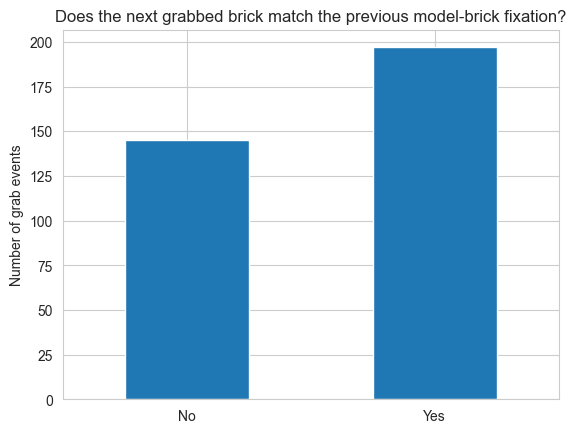

In [150]:
import matplotlib.pyplot as plt

plot_data = (
    grab_fixation_matches["grab_matches_previous_model_fixation"]
    .map({True: "Yes", False: "No"})
    .value_counts()
    .reindex(["No", "Yes"], fill_value=0)
)

ax = plot_data.plot(kind="bar")

ax.set_title("Does the next grabbed brick match the previous model-brick fixation?")
ax.set_xlabel("")
ax.set_ylabel("Number of grab events")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)

plt.show()

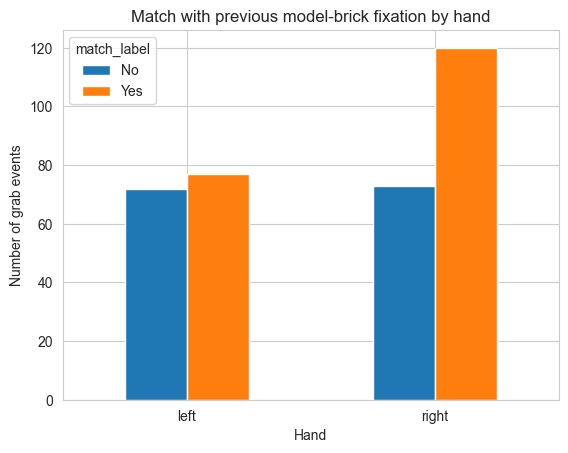

In [151]:
hand_counts = (
    grab_fixation_matches
    .dropna(subset=["grab_matches_previous_model_fixation"])
    .assign(
        match_label=lambda x: x["grab_matches_previous_model_fixation"]
        .map({True: "Yes", False: "No"})
    )
    .groupby(["grab_hand", "match_label"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=["No", "Yes"], fill_value=0)
)

hand_counts.plot(kind="bar")

plt.title("Match with previous model-brick fixation by hand")
plt.xlabel("Hand")
plt.ylabel("Number of grab events")
plt.xticks(rotation=0)
plt.show()

In [152]:
plot_df = grab_fixation_matches.copy()

plot_df = plot_df[plot_df["grab_matches_previous_model_fixation"].notna()].copy()

plot_df["match_label"] = plot_df["grab_matches_previous_model_fixation"].map({
    True: "Yes",
    False: "No",
})

plot_df["match_numeric"] = plot_df["grab_matches_previous_model_fixation"].astype(int)

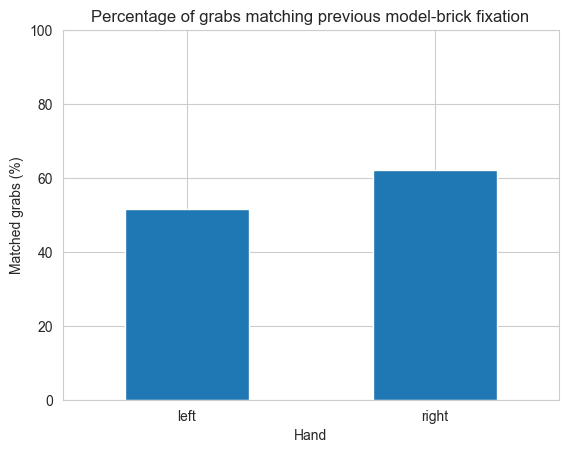

In [153]:
match_rate_by_hand = (
    plot_df
    .groupby("grab_hand")["match_numeric"]
    .mean()
    .mul(100)
)

ax = match_rate_by_hand.plot(kind="bar")

ax.set_title("Percentage of grabs matching previous model-brick fixation")
ax.set_xlabel("Hand")
ax.set_ylabel("Matched grabs (%)")
ax.set_ylim(0, 100)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)

plt.show()

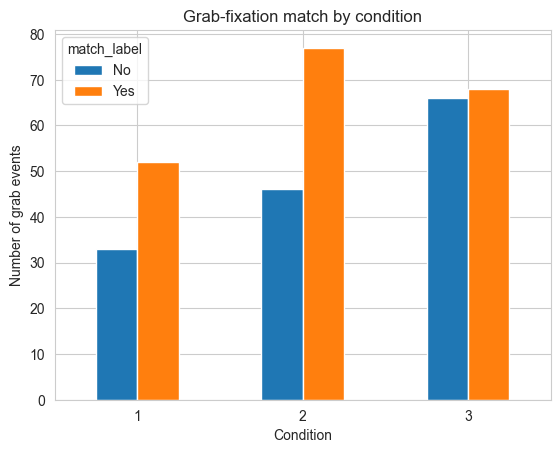

In [154]:
condition_counts = (
    plot_df
    .groupby(["condition_number", "match_label"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=["No", "Yes"], fill_value=0)
)

ax = condition_counts.plot(kind="bar")

ax.set_title("Grab-fixation match by condition")
ax.set_xlabel("Condition")
ax.set_ylabel("Number of grab events")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)

plt.show()

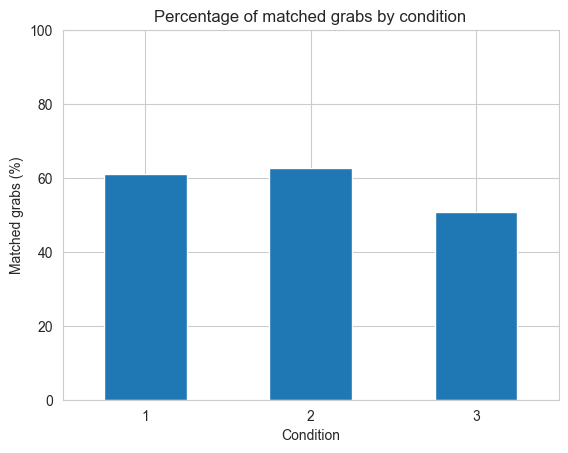

In [155]:
condition_rate = (
    plot_df
    .groupby("condition_number")["match_numeric"]
    .mean()
    .mul(100)
)

ax = condition_rate.plot(kind="bar")

ax.set_title("Percentage of matched grabs by condition")
ax.set_xlabel("Condition")
ax.set_ylabel("Matched grabs (%)")
ax.set_ylim(0, 100)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)

plt.show()

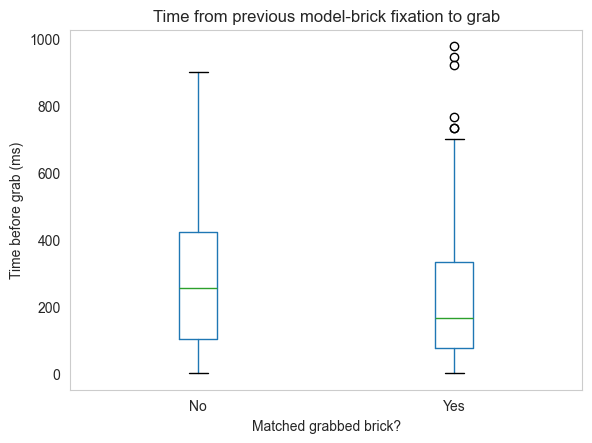

In [156]:
ax = plot_df.boxplot(
    column="time_since_previous_fixation_ms",
    by="match_label",
    grid=False
)

plt.title("Time from previous model-brick fixation to grab")
plt.suptitle("")
plt.xlabel("Matched grabbed brick?")
plt.ylabel("Time before grab (ms)")

plt.show()

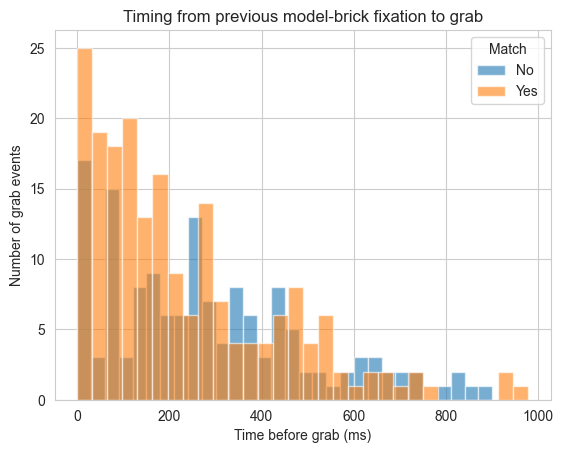

In [157]:
for label in ["No", "Yes"]:
    subset = plot_df[plot_df["match_label"] == label]
    plt.hist(
        subset["time_since_previous_fixation_ms"].dropna(),
        bins=30,
        alpha=0.6,
        label=label,
    )

plt.title("Timing from previous model-brick fixation to grab")
plt.xlabel("Time before grab (ms)")
plt.ylabel("Number of grab events")
plt.legend(title="Match")

plt.show()

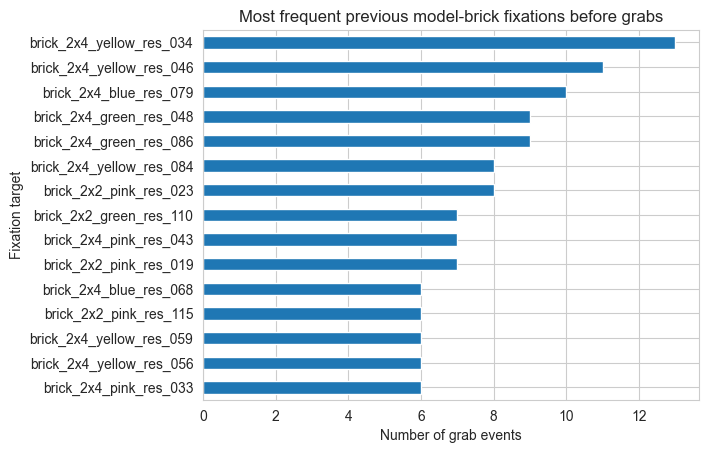

In [158]:
top_fixated = (
    plot_df["fixation_target"]
    .value_counts()
    .head(15)
)

ax = top_fixated.plot(kind="barh")

ax.set_title("Most frequent previous model-brick fixations before grabs")
ax.set_xlabel("Number of grab events")
ax.set_ylabel("Fixation target")

plt.gca().invert_yaxis()
plt.show()

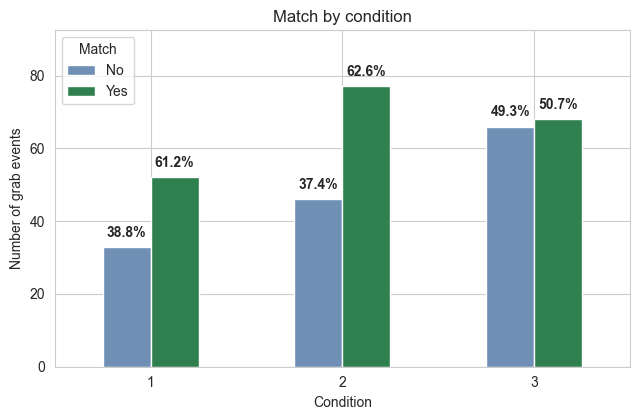

In [161]:
import matplotlib.pyplot as plt

condition_counts = (
    grab_fixation_matches
    .dropna(subset=["grab_matches_previous_model_fixation"])
    .assign(
        match_label=lambda x: x["grab_matches_previous_model_fixation"]
        .map({True: "Yes", False: "No"})
    )
    .groupby(["condition_number", "match_label"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=["No", "Yes"], fill_value=0)
)

condition_percentages = condition_counts.div(condition_counts.sum(axis=1), axis=0) * 100

ax = condition_counts.plot(
    kind="bar",
    color=["#6f8fb5", "#2f7f4f"],
    figsize=(6.5, 4.3),
)

ax.set_title("Match by condition")
ax.set_xlabel("Condition")
ax.set_ylabel("Number of grab events")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(title="Match")

for container, match_label in zip(ax.containers, condition_counts.columns):
    for bar, condition in zip(container, condition_counts.index):
        height = bar.get_height()
        percent = condition_percentages.loc[condition, match_label]

        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + condition_counts.to_numpy().max() * 0.025,
            f"{percent:.1f}%",
            ha="center",
            va="bottom",
            fontsize=10,
            fontweight="bold",
        )

ax.set_ylim(0, condition_counts.to_numpy().max() * 1.2)

plt.tight_layout()
plt.show()

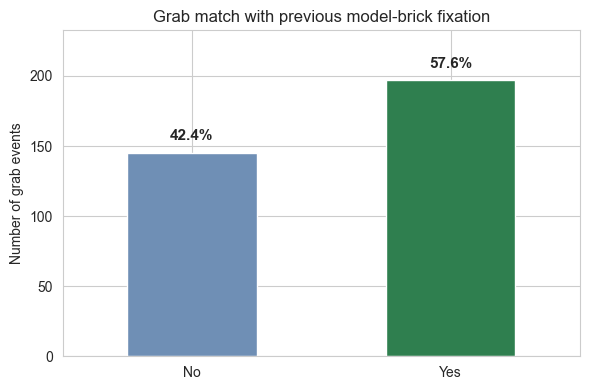

In [159]:
import matplotlib.pyplot as plt

plot_data = (
    grab_fixation_matches["grab_matches_previous_model_fixation"]
    .map({True: "Yes", False: "No"})
    .value_counts()
    .reindex(["No", "Yes"], fill_value=0)
)

total = plot_data.sum()
percentages = plot_data / total * 100

ax = plot_data.plot(
    kind="bar",
    color=["#6f8fb5", "#2f7f4f"],
    figsize=(6, 4),
)

ax.set_title("Grab match with previous model-brick fixation")
ax.set_xlabel("")
ax.set_ylabel("Number of grab events")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)

for i, value in enumerate(plot_data):
    percent = percentages.iloc[i]
    ax.text(
        i,
        value + total * 0.02,
        f"{percent:.1f}%",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold",
    )

ax.set_ylim(0, plot_data.max() * 1.18)

plt.tight_layout()
plt.show()

In [ ]:
df["bt_"]

In [130]:
number_of_fixations = df["fixation_id"].nunique()

number_of_fixations

9947

In [131]:
df

,gaze_capture_time,raw_timestamp,relative_to_unix_epoch_timestamp,focus_distance,frame_number,stability,status,gaze_forward_x,gaze_forward_y,gaze_forward_z,...,bt_RightGrab_obj_rot_z,bt_RightGrab_obj_rot_w,bt_model_name,bt_model_rot_deg,bt_LeftFootArea,bt_RightFootArea,bt_raw_timestamp_diff_ms,bt_unix_timestamp_diff_ms,lefthand_grab_id,righthand_grab_id
0,1000001886734534500,1778060668925,996.9191,2.000000,312947,0.683982,Valid,0.031344,0.294718,0.955070,...,0.0,1.0,C1M5F,0.0,Work,Work,0.0,0.0,<NA>,<NA>
1,1000001886739535200,1778060668925,996.9191,2.000000,312948,0.682689,Valid,0.031658,0.294867,0.955014,...,0.0,1.0,C1M5F,0.0,Work,Work,0.0,0.0,<NA>,<NA>
2,1000001886744543200,1778060668934,996.9284,2.000000,312949,0.749988,Valid,0.031943,0.294998,0.954964,...,0.0,1.0,C1M5F,0.0,Work,Work,1.0,0.0,<NA>,<NA>
3,1000001886749543300,1778060668934,996.9284,2.000000,312950,0.851914,Valid,0.032383,0.294995,0.954950,...,0.0,1.0,C1M5F,0.0,Work,Work,1.0,0.0,<NA>,<NA>
4,1000001886754542400,1778060668945,996.9396,2.000000,312951,1.000000,Valid,0.032786,0.294996,0.954936,...,0.0,1.0,C1M5F,0.0,Work,Work,0.0,0.0,<NA>,<NA>
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
354377,1000005088780099400,1778063870984,3723.7470,0.583587,953108,0.912354,Valid,0.229579,-0.162637,0.959606,...,0.0,1.0,C1M1F,0.0,Work,Work,1.0,0.0,<NA>,413
354378,1000005088785100000,1778063870984,3723.7470,0.583548,953109,0.906667,Valid,0.229546,-0.162617,0.959617,...,0.0,1.0,C1M1F,0.0,Work,Work,1.0,0.0,<NA>,413
354379,1000005088790100900,1778063870984,3723.7470,0.583413,953110,0.888851,Valid,0.229516,-0.162539,0.959637,...,0.0,1.0,C1M1F,0.0,Work,Work,1.0,0.0,<NA>,413
354380,1000005088795101500,1778063870984,3723.7470,0.583175,953111,0.873793,Valid,0.229448,-0.162440,0.959670,...,0.0,1.0,C1M1F,0.0,Work,Work,1.0,0.0,<NA>,413


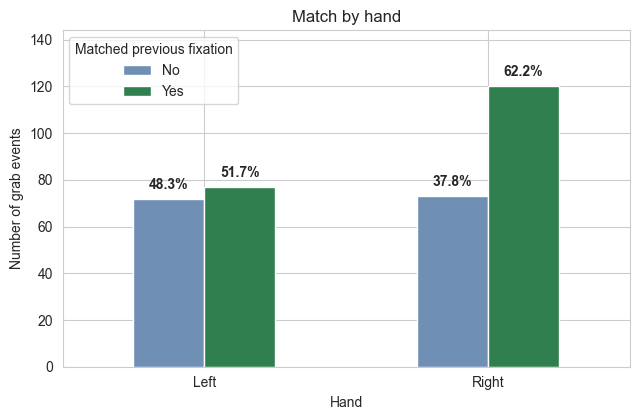

In [160]:
import matplotlib.pyplot as plt

hand_counts = (
    grab_fixation_matches
    .dropna(subset=["grab_matches_previous_model_fixation"])
    .assign(
        match_label=lambda x: x["grab_matches_previous_model_fixation"]
        .map({True: "Yes", False: "No"})
    )
    .groupby(["grab_hand", "match_label"])
    .size()
    .unstack(fill_value=0)
    .reindex(index=["left", "right"])
    .reindex(columns=["No", "Yes"], fill_value=0)
)

hand_percentages = hand_counts.div(hand_counts.sum(axis=1), axis=0) * 100

ax = hand_counts.plot(
    kind="bar",
    color=["#6f8fb5", "#2f7f4f"],
    figsize=(6.5, 4.3),
)

ax.set_title("Match by hand")
ax.set_xlabel("Hand")
ax.set_ylabel("Number of grab events")
ax.set_xticklabels(["Left", "Right"], rotation=0)
ax.legend(title="Matched previous fixation")

for container, match_label in zip(ax.containers, hand_counts.columns):
    for bar, hand in zip(container, hand_counts.index):
        height = bar.get_height()
        percent = hand_percentages.loc[hand, match_label]

        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + hand_counts.to_numpy().max() * 0.025,
            f"{percent:.1f}%",
            ha="center",
            va="bottom",
            fontsize=10,
            fontweight="bold",
        )

ax.set_ylim(0, hand_counts.to_numpy().max() * 1.2)

plt.tight_layout()
plt.show()

## Plots

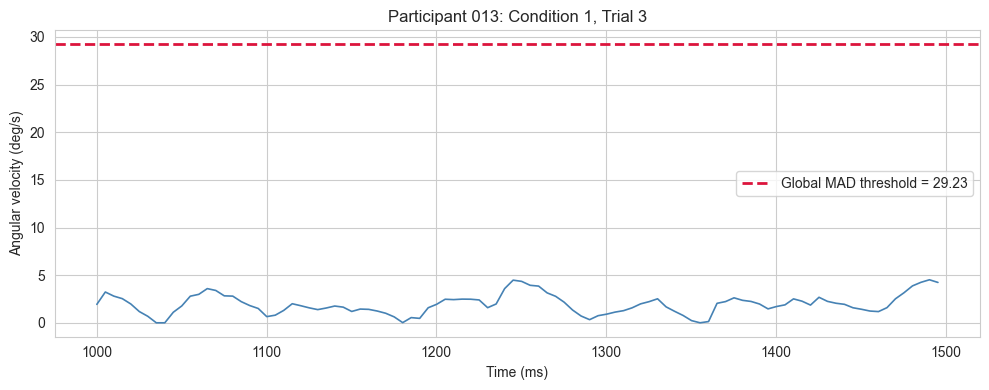

In [128]:
cond = 1
trial = 3

sub = df[
    (df["condition_number"] == cond) &
    (df["trial_number"] == trial) &
    (df["time_ms"]  > 1000) &
    (df["time_ms"]  < 1500)
].copy()

sub["angular_velocity"] = pd.to_numeric(sub["angular_velocity"], errors="coerce")
sub["time_ms"] = pd.to_numeric(sub["time_ms"], errors="coerce")

vel_all = pd.to_numeric(df["angular_velocity"], errors="coerce")
vel_all = vel_all[np.isfinite(vel_all)]

global_mad_threshold, global_trace = at_mad_threshold(vel_all, th_0=200.0)

plt.figure(figsize=(10, 4))
plt.plot(sub["time_ms"], sub["angular_velocity"], lw=1.2, color="steelblue")
plt.axhline(
    global_mad_threshold,
    color="crimson",
    ls="--",
    lw=2,
    label=f"Global MAD threshold = {global_mad_threshold:.2f}"
)
f"Participant {participant_id}: Condition {cond}, Trial {trial}"
plt.xlabel("Time (ms)")
plt.ylabel("Angular velocity (deg/s)")
plt.title(f"Participant {participant_id}: Condition {cond}, Trial {trial}")
plt.legend()
plt.tight_layout()
plt.show()

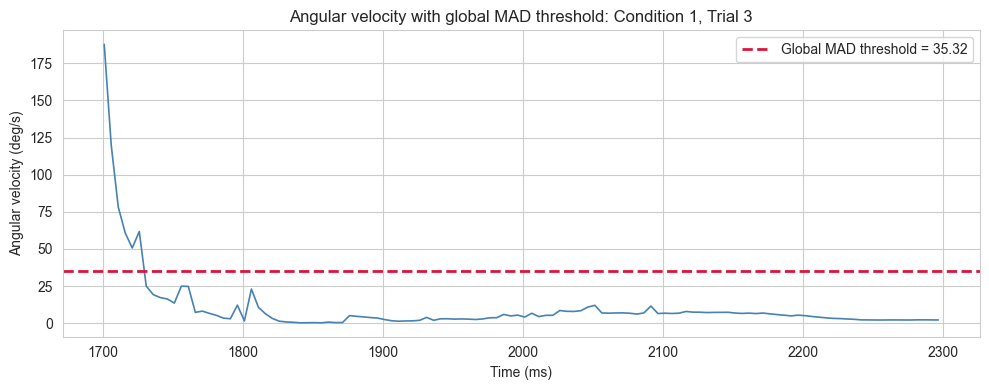

In [132]:
cond = 1
trial = 3

sub = df[
    (df["condition_number"] == cond) &
    (df["trial_number"] == trial) &
    (df["time_ms"]  > 1700) &
    (df["time_ms"]  < 2300)
].copy()

sub["angular_velocity"] = pd.to_numeric(sub["angular_velocity"], errors="coerce")
sub["time_ms"] = pd.to_numeric(sub["time_ms"], errors="coerce")

vel_all = pd.to_numeric(df["angular_velocity"], errors="coerce")
vel_all = vel_all[np.isfinite(vel_all)]

global_mad_threshold, global_trace = at_mad_threshold(vel_all, th_0=200.0)

plt.figure(figsize=(10, 4))
plt.plot(sub["time_ms"], sub["angular_velocity"], lw=1.2, color="steelblue")
plt.axhline(
    global_mad_threshold,
    color="crimson",
    ls="--",
    lw=2,
    label=f"Global MAD threshold = {global_mad_threshold:.2f}"
)

plt.xlabel("Time (ms)")
plt.ylabel("Angular velocity (deg/s)")
plt.title(f"Angular velocity with global MAD threshold: Condition {cond}, Trial {trial}")
plt.legend()
plt.tight_layout()
plt.show()

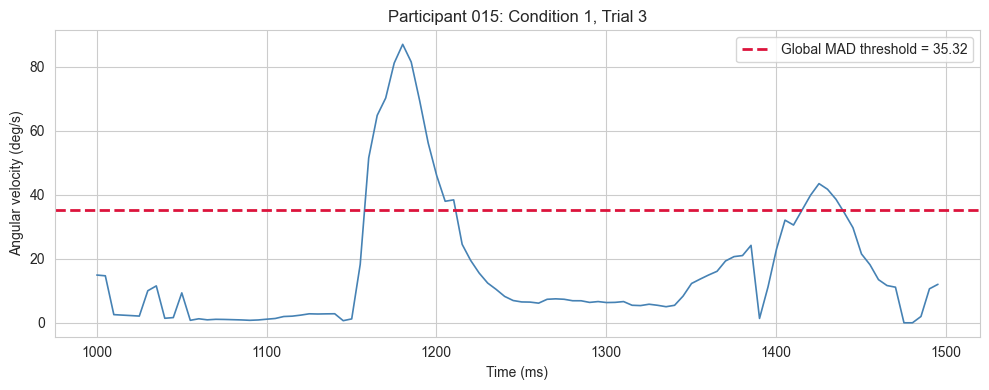

In [133]:
cond = 1
trial = 3

sub = df[
    (df["condition_number"] == cond) &
    (df["trial_number"] == trial) &
    (df["time_ms"] > 1000) &
    (df["time_ms"] < 1500)
].copy()

sub["angular_velocity"] = pd.to_numeric(sub["angular_velocity"], errors="coerce")
sub["time_ms"] = pd.to_numeric(sub["time_ms"], errors="coerce")

participant_id = sub["participant_id"].iloc[0]

vel_all = pd.to_numeric(df["angular_velocity"], errors="coerce")
vel_all = vel_all[np.isfinite(vel_all)]

global_mad_threshold, global_trace = at_mad_threshold(vel_all, th_0=200.0)

plt.figure(figsize=(10, 4))
plt.plot(sub["time_ms"], sub["angular_velocity"], lw=1.2, color="steelblue")
plt.axhline(
    global_mad_threshold,
    color="crimson",
    ls="--",
    lw=2,
    label=f"Global MAD threshold = {global_mad_threshold:.2f}"
)

plt.xlabel("Time (ms)")
plt.ylabel("Angular velocity (deg/s)")
plt.title(
    f"Participant {participant_id}: Condition {cond}, Trial {trial}"
)
plt.legend()
plt.tight_layout()
plt.show()


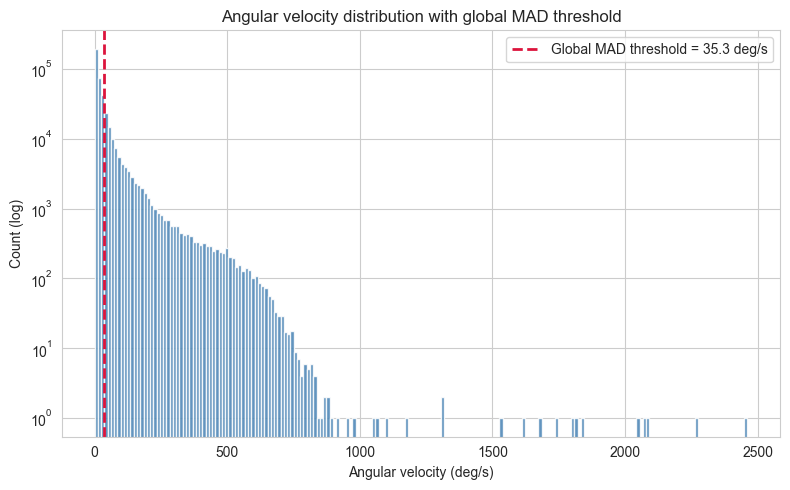

In [134]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

vel = pd.to_numeric(df["angular_velocity"], errors="coerce")
vel = vel[np.isfinite(vel)]

global_mad_threshold, global_trace = at_mad_threshold(vel, th_0=200.0)

plt.figure(figsize=(8, 5))
plt.hist(vel, bins=200, color="steelblue", alpha=0.85)
plt.yscale("log")

plt.axvline(
    global_mad_threshold,
    color="crimson",
    linestyle="--",
    linewidth=2,
    label=f"Global MAD threshold = {global_mad_threshold:.1f} deg/s"
)

plt.xlabel("Angular velocity (deg/s)")
plt.ylabel("Count (log)")
plt.title("Angular velocity distribution with global MAD threshold")
plt.legend()
plt.tight_layout()
plt.show()


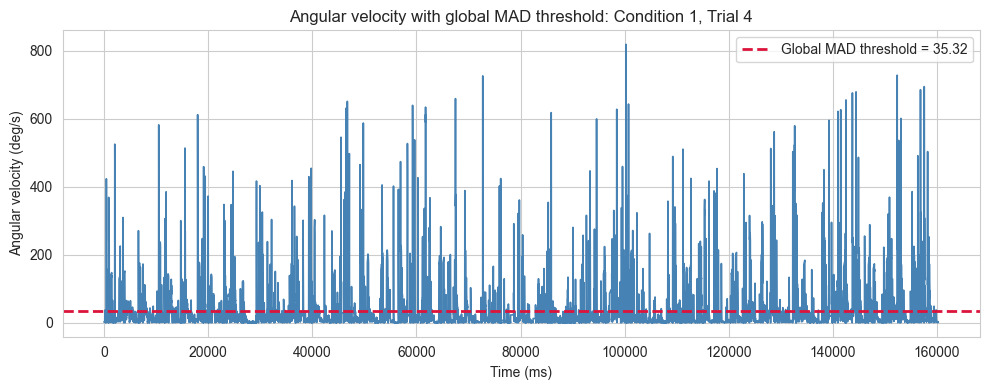

In [135]:
cond = 1
trial = 4

sub = df[
    (df["condition_number"] == cond) &
    (df["trial_number"] == trial)
].copy()

sub["angular_velocity"] = pd.to_numeric(sub["angular_velocity"], errors="coerce")
sub["time_ms"] = pd.to_numeric(sub["time_ms"], errors="coerce")

vel_all = pd.to_numeric(df["angular_velocity"], errors="coerce")
vel_all = vel_all[np.isfinite(vel_all)]

global_mad_threshold, global_trace = at_mad_threshold(vel_all, th_0=200.0)

plt.figure(figsize=(10, 4))
plt.plot(sub["time_ms"], sub["angular_velocity"], lw=1.2, color="steelblue")
plt.axhline(
    global_mad_threshold,
    color="crimson",
    ls="--",
    lw=2,
    label=f"Global MAD threshold = {global_mad_threshold:.2f}"
)

plt.xlabel("Time (ms)")
plt.ylabel("Angular velocity (deg/s)")
plt.title(f"Angular velocity with global MAD threshold: Condition {cond}, Trial {trial}")
plt.legend()
plt.tight_layout()
plt.show()

In [25]:
df

,gaze_capture_time,raw_timestamp,relative_to_unix_epoch_timestamp,focus_distance,frame_number,stability,status,gaze_forward_x,gaze_forward_y,gaze_forward_z,...,clean_gaze_forward_x,clean_gaze_forward_y,clean_gaze_forward_z,segment_label,angular_velocity,mad_threshold,velocity_category,saccade_id,fixation_id,event_duration_ms
0,1000022788285652000,1778685795519,668.5797,0.652126,439037,1.000000,Valid,0.109160,-0.226190,0.967947,...,0.109211,-0.226069,0.967970,C1_T0,NaN,35.323614,<NA>,<NA>,<NA>,NaN
1,1000022788290664100,1778685795519,668.5797,0.651707,439038,1.000000,Valid,0.109225,-0.226069,0.967968,...,0.109205,-0.226028,0.967980,C1_T0,0.485644,35.323614,fixation,<NA>,1,105.0126
2,1000022788295662400,1778685795519,668.5797,0.652404,439039,1.000000,Valid,0.109210,-0.225987,0.967989,...,0.109199,-0.225988,0.967990,C1_T0,0.486984,35.323614,fixation,<NA>,1,105.0126
3,1000022788300662400,1778685795520,668.5797,0.653702,439040,1.000000,Valid,0.109199,-0.225889,0.968013,...,0.109199,-0.225889,0.968013,C1_T0,1.154406,35.323614,fixation,<NA>,1,105.0126
4,1000022788305662400,1778685795520,668.5797,0.659967,439041,0.816025,Valid,0.108934,-0.223826,0.968522,...,0.108929,-0.225061,0.968236,C1_T0,10.302810,35.323614,fixation,<NA>,1,105.0126
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
407138,1000026075651581400,1778689082830,2981.4480,2.000000,1096257,0.000000,Valid,-0.217461,0.038505,0.975309,...,-0.217461,0.038505,0.975309,C3_T6,64.008845,35.323614,saccade,11630,<NA>,125.0175
407139,1000026075656582100,1778689082841,2981.4590,2.000000,1096258,0.000000,Valid,-0.211815,0.038285,0.976560,...,-0.211815,0.038285,0.976559,C3_T6,66.303737,35.323614,saccade,11630,<NA>,125.0175
407140,1000026075661582800,1778689082841,2981.4590,2.000000,1096259,0.000000,Valid,-0.207879,0.037943,0.977418,...,-0.207879,0.037943,0.977418,C3_T6,46.328163,35.323614,saccade,11630,<NA>,125.0175
407141,1000026075666583900,1778689082853,2981.4700,2.000000,1096260,0.000000,Valid,-0.203904,0.037544,0.978271,...,-0.205892,0.037743,0.977847,C3_T6,23.400405,35.323614,fixation,<NA>,11650,10.0014


In [9]:
df["trial_number"].value_counts()

trial_number
2    106543
4    102036
1     82245
3     71251
6     67567
5     66770
0     57066
Name: count, dtype: int64

In [10]:
df["condition_number"].value_counts()

condition_number
2    211218
3    184443
1    157817
Name: count, dtype: int64

In [11]:
df["participant_id"].value_counts()

participant_id
001    553478
Name: count, dtype: int64

In [27]:
df = add_saccade_fixation_ids(df)

In [106]:
df

,gaze_capture_time,raw_timestamp,relative_to_unix_epoch_timestamp,focus_distance,frame_number,stability,status,gaze_forward_x,gaze_forward_y,gaze_forward_z,...,clean_gaze_forward_x,clean_gaze_forward_y,clean_gaze_forward_z,segment_label,angular_velocity,mad_threshold,velocity_category,saccade_id,fixation_id,event_duration_ms
0,1000012274065305300,1778675281294,805.1057,1.038138,577494,0.000000,Valid,-0.171002,-0.269741,0.947628,...,-0.175491,-0.270143,0.946692,C1_T0,NaN,32.4762,<NA>,<NA>,<NA>,NaN
1,1000012274070305400,1778675281294,805.1057,1.036370,577495,0.000000,Valid,-0.175491,-0.270143,0.946692,...,-0.177513,-0.270270,0.946279,C1_T0,23.692742,32.4762,fixation,<NA>,1,10.0014
2,1000012274075306000,1778675281294,805.1057,1.020933,577496,0.000000,Valid,-0.179534,-0.270396,0.945861,...,-0.179534,-0.270396,0.945861,C1_T0,23.690374,32.4762,fixation,<NA>,1,10.0014
3,1000012274080306600,1778675281294,805.1057,0.995371,577497,0.000000,Valid,-0.183421,-0.270438,0.945103,...,-0.183423,-0.270399,0.945114,C1_T0,45.373171,32.4762,saccade,1,<NA>,15.0021
4,1000012274085307200,1778675281294,805.1057,0.953432,577498,0.000000,Valid,-0.187101,-0.270486,0.944368,...,-0.187105,-0.270403,0.944391,C1_T0,42.995471,32.4762,saccade,1,<NA>,15.0021
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
483692,1000015936734767900,1778678943921,3684.2150,2.000000,1309746,0.722730,Valid,0.134560,-0.058735,0.989163,...,NaN,NaN,NaN,C3_T6,NaN,32.4762,<NA>,<NA>,<NA>,NaN
483693,1000015936739766800,1778678943921,3684.2150,2.000000,1309747,0.534784,Valid,0.133979,-0.061550,0.989071,...,NaN,NaN,NaN,C3_T6,NaN,32.4762,<NA>,<NA>,<NA>,NaN
483694,1000015936744766900,1778678943933,3684.2260,2.000000,1309748,0.000000,Valid,0.134756,-0.059061,0.989117,...,NaN,NaN,NaN,C3_T6,NaN,32.4762,<NA>,<NA>,<NA>,NaN
483695,1000015937120816200,1778678944299,3684.5930,2.000000,1309823,0.000000,Valid,0.119805,-0.095041,0.988238,...,NaN,NaN,NaN,C3_T6,NaN,32.4762,<NA>,<NA>,<NA>,NaN


In [52]:
df.head()

,gaze_capture_time,raw_timestamp,relative_to_unix_epoch_timestamp,focus_distance,frame_number,stability,status,gaze_forward_x,gaze_forward_y,gaze_forward_z,...,clean_gaze_forward_x,clean_gaze_forward_y,clean_gaze_forward_z,segment_label,angular_velocity,mad_threshold,velocity_category,saccade_id,fixation_id,event_duration_ms
0,1000100376904928200,1778826383977,591.5391,1.023939,64073,0.789749,Valid,-0.232266,-0.191211,0.953673,...,-0.231575,-0.191438,0.953795,C1_T0,NaN,25.809083,<NA>,<NA>,<NA>,NaN
1,1000100376909927100,1778826383977,591.5391,1.005479,64074,0.784619,Valid,-0.231575,-0.191438,0.953795,...,-0.231171,-0.191596,0.953861,C1_T0,5.032963,25.809083,fixation,<NA>,1,80.0096
2,1000100376914927900,1778826383977,591.5391,0.984855,64075,0.788606,Valid,-0.230766,-0.191753,0.953928,...,-0.230766,-0.191753,0.953928,C1_T0,5.031051,25.809083,fixation,<NA>,1,80.0096
3,1000100376919928700,1778826383977,591.5391,0.963226,64076,0.777880,Valid,-0.229765,-0.191962,0.954127,...,-0.229765,-0.191961,0.954127,C1_T0,11.940895,25.809083,fixation,<NA>,1,80.0096
4,1000100376924937100,1778826383977,591.5391,0.944364,64077,0.773483,Valid,-0.228605,-0.192091,0.954380,...,-0.228611,-0.191966,0.954404,C1_T0,13.576025,25.809083,fixation,<NA>,1,80.0096


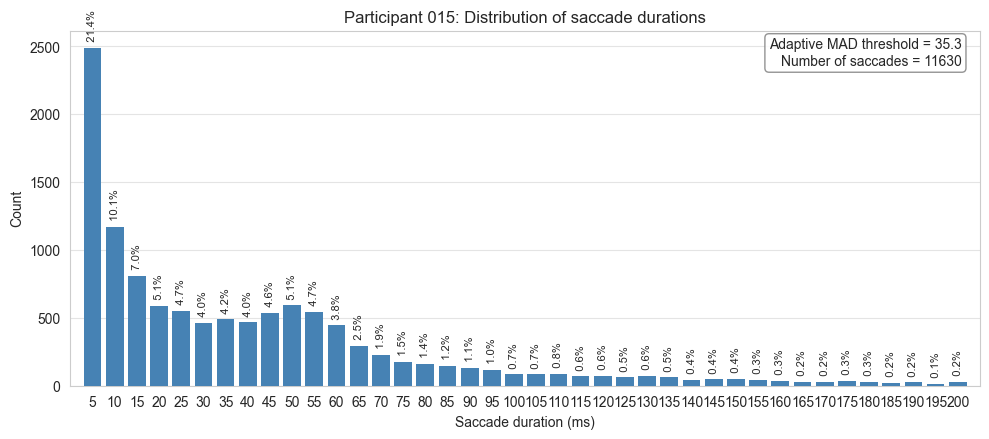

In [136]:
import pandas as pd
import matplotlib.pyplot as plt

# One row per saccade event
saccade_events = (
    df.dropna(subset=["saccade_id"])
      .groupby("saccade_id", as_index=False)
      .agg(duration_ms=("event_duration_ms", "first"))
)

# Keep only durations from 5 to 200 ms
saccade_events_plot = saccade_events[
    (saccade_events["duration_ms"] >= 5) &
    (saccade_events["duration_ms"] <= 205)
].copy()

# Round durations to nearest 5 ms
saccade_events_plot["duration_bin"] = (
    5 * (saccade_events_plot["duration_ms"] / 5).round()
).astype(int)

# Count saccades per 5 ms bin
duration_counts = (
    saccade_events_plot["duration_bin"]
    .value_counts()
    .sort_index()
)

# Total number of all saccade events
total_saccades = saccade_events["saccade_id"].nunique()

fig, ax = plt.subplots(figsize=(10, 4.5))

ax.bar(
    duration_counts.index,
    duration_counts.values,
    width=4.0,
    color="steelblue",
    linewidth=0,
    zorder=3
)

# One percentage above each bar
for x, count in zip(duration_counts.index, duration_counts.values):
    pct = 100 * count / total_saccades
    ax.text(
        x,
        count + 3,
        f"  {pct:.1f}%",
        ha="center",
        va="bottom",
        fontsize=8,
        rotation=90
    )
info_text = (
    f"Adaptive MAD threshold = {global_mad_threshold:.1f}\n"
    f"Number of saccades = {total_saccades}"
)
ax.text(
    0.98, 0.98,
    info_text,
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=10,
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.85, edgecolor="gray")
)

ax.set_axisbelow(True)
ax.grid(axis="y", color="lightgray", alpha=0.6, zorder=0)
ax.grid(axis="x", visible=False)

ax.set_xlabel("Saccade duration (ms)")
ax.set_ylabel("Count")
ax.set_title(f"Participant {participant_id}: Distribution of saccade durations")

ax.set_xticks(range(5, 205, 5))
ax.set_xlim(0, 205)

plt.tight_layout()
plt.show()


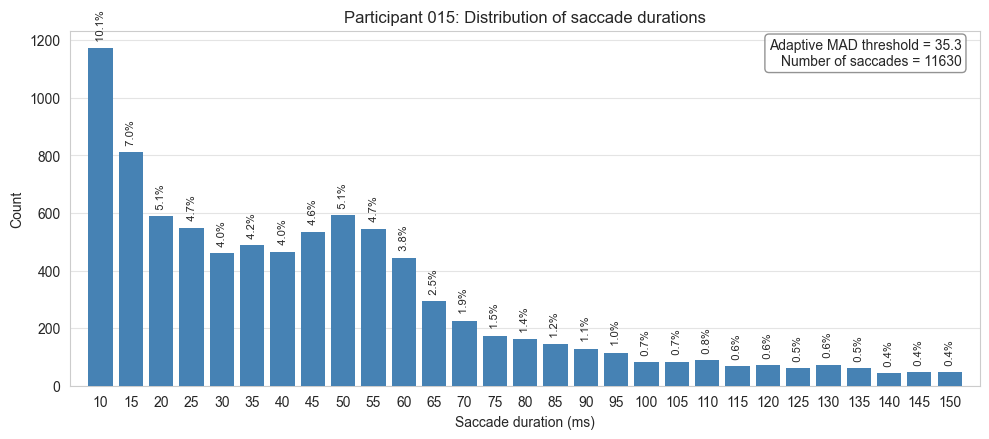

In [137]:
import pandas as pd
import matplotlib.pyplot as plt

# One row per saccade event
saccade_events = (
    df.dropna(subset=["saccade_id"])
      .groupby("saccade_id", as_index=False)
      .agg(duration_ms=("event_duration_ms", "first"))
)

# Keep only durations from 5 to 200 ms
saccade_events_plot = saccade_events[
    (saccade_events["duration_ms"] >= 10) &
    (saccade_events["duration_ms"] <= 155)
].copy()

# Round durations to nearest 5 ms
saccade_events_plot["duration_bin"] = (
    5 * (saccade_events_plot["duration_ms"] / 5).round()
).astype(int)

# Count saccades per 5 ms bin
duration_counts = (
    saccade_events_plot["duration_bin"]
    .value_counts()
    .sort_index()
)

# Total number of all saccade events
total_saccades = saccade_events["saccade_id"].nunique()

fig, ax = plt.subplots(figsize=(10, 4.5))

ax.bar(
    duration_counts.index,
    duration_counts.values,
    width=4.0,
    color="steelblue",
    linewidth=0,
    zorder=3
)

# One percentage above each bar
for x, count in zip(duration_counts.index, duration_counts.values):
    pct = 100 * count / total_saccades
    ax.text(
        x,
        count + 3,
        f"  {pct:.1f}%",
        ha="center",
        va="bottom",
        fontsize=8,
        rotation=90
    )
info_text = (
    f"Adaptive MAD threshold = {global_mad_threshold:.1f}\n"
    f"Number of saccades = {total_saccades}"
)
ax.text(
    0.98, 0.98,
    info_text,
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=10,
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.85, edgecolor="gray")
)
ax.set_axisbelow(True)
ax.grid(axis="y", color="lightgray", alpha=0.6, zorder=0)
ax.grid(axis="x", visible=False)

ax.set_xlabel("Saccade duration (ms)")
ax.set_ylabel("Count")
ax.set_title(f"Participant {participant_id}: Distribution of saccade durations")

ax.set_xticks(range(10, 155, 5))
ax.set_xlim(5, 155)

plt.tight_layout()
plt.show()


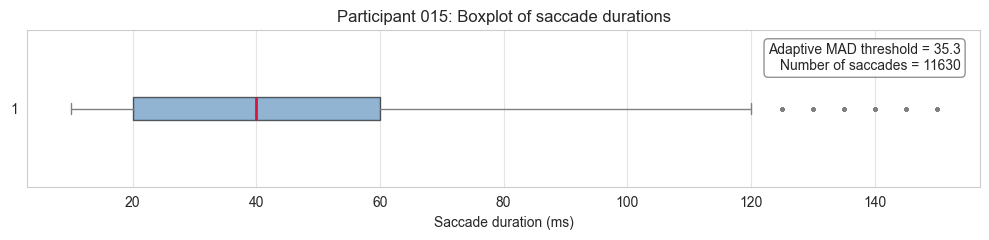

In [138]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 2.5))

ax.boxplot(
    saccade_events_plot["duration_ms"].dropna(),
    vert=False,
    patch_artist=True,
    boxprops=dict(facecolor="steelblue", alpha=0.6),
    medianprops=dict(color="crimson", linewidth=2),
    whiskerprops=dict(color="gray"),
    capprops=dict(color="gray"),
    flierprops=dict(marker="o", markerfacecolor="gray", markersize=3, alpha=0.4, markeredgecolor="none")
)

info_text = (
    f"Adaptive MAD threshold = {global_mad_threshold:.1f}\n"
    f"Number of saccades = {total_saccades}"
)

ax.text(
    0.98, 0.92,
    info_text,
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=10,
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.85, edgecolor="gray")
)

ax.set_xlabel("Saccade duration (ms)")
ax.set_title(f"Participant {participant_id}: Boxplot of saccade durations")
ax.grid(axis="x", color="lightgray", alpha=0.6)
ax.grid(axis="y", visible=False)

plt.tight_layout()
plt.show()


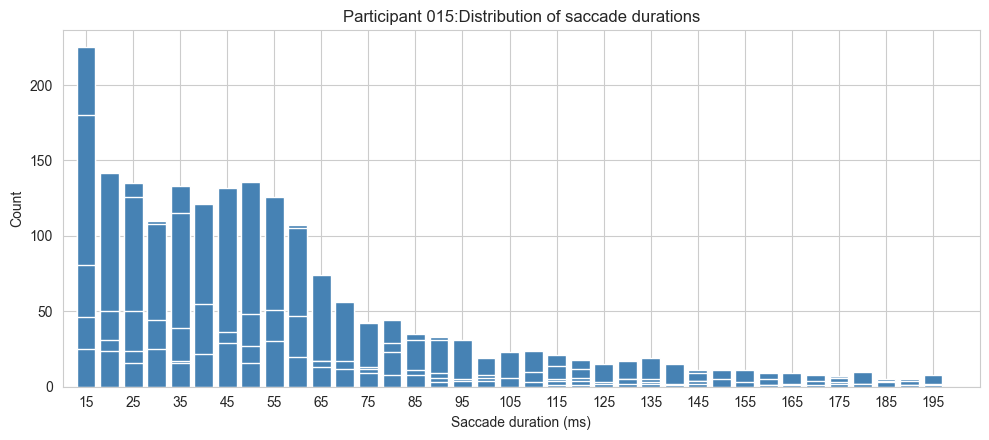

In [139]:
import pandas as pd
import matplotlib.pyplot as plt

# One row per saccade event
saccade_events = (
    df.dropna(subset=["saccade_id"])
      .groupby("saccade_id", as_index=False)
      .agg(duration_ms=("event_duration_ms", "first"))
)

# Optional: focus on the main range
saccade_events_plot = saccade_events[
    (saccade_events["duration_ms"] >= 15) &
    (saccade_events["duration_ms"] <= 200)
].copy()

# Count exact duration values (5, 10, 15, ...)
duration_counts = (
    saccade_events_plot["duration_ms"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(10, 4.5))
plt.bar(
    duration_counts.index,
    duration_counts.values,
    width=4.0,
    color="steelblue"
)

plt.xlabel("Saccade duration (ms)")
plt.ylabel("Count")
plt.title(f"Participant {participant_id}:Distribution of saccade durations")
plt.xticks(range(15, 205, 10))
plt.xlim(10, 205)
plt.tight_layout()
plt.show()


In [140]:
# Basic summary
n_saccades = len(saccade_events)
max_duration = saccade_events["duration_ms"].max()
mean_duration = saccade_events["duration_ms"].mean()
median_duration = saccade_events["duration_ms"].median()

print(f"Participant:{participant_id}")
print("Number of saccades:", n_saccades)
print("Maximum saccade duration (ms):", max_duration)
print("Mean of saccade duration (ms):", mean_duration)
print("Median duration (ms):", median_duration)


Participant:015
Number of saccades: 11630
Maximum saccade duration (ms): 455.0636999999995
Mean of saccade duration (ms): 44.18672604469498
Median duration (ms): 30.003600000018196


In [141]:
print(f"Participant:{participant_id}")
print(saccade_events["duration_ms"].describe())

Participant:015
count    11630.000000
mean        44.186726
std         49.604619
min          5.000500
25%         10.001200
50%         30.003600
75%         60.007200
max        455.063700
Name: duration_ms, dtype: float64


In [68]:
largest_saccades = saccade_events.sort_values("duration_ms", ascending=False).head(10)
largest_saccades

,saccade_id,duration_ms
1848,1849,965.1351
2348,2349,600.0840
7573,7574,595.0714
14925,14926,590.0708
536,537,570.0798
17151,17152,570.0684
16932,16933,545.0654
1042,1043,525.0735
3441,3442,510.0714
17590,17591,500.0600


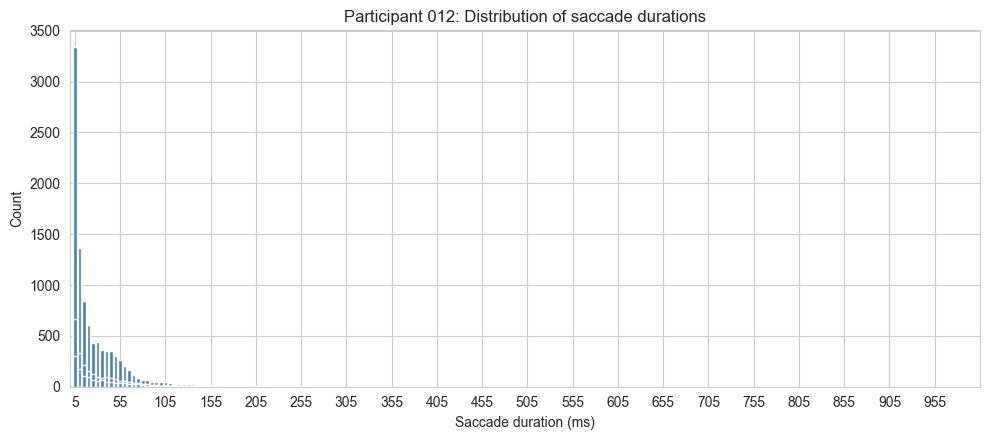

In [65]:
import pandas as pd
import matplotlib.pyplot as plt

# One row per saccade event
saccade_events = (
    df.dropna(subset=["saccade_id"])
      .groupby("saccade_id", as_index=False)
      .agg(duration_ms=("event_duration_ms", "first"))
)

# Optional: focus on the main range
saccade_events_plot = saccade_events[
    saccade_events["duration_ms"] <= 1000
].copy()

# Count exact duration values (5, 10, 15, ...)
duration_counts = (
    saccade_events_plot["duration_ms"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(10, 4.5))
plt.bar(
    duration_counts.index,
    duration_counts.values,
    width=4.0,
    color="steelblue"
)

plt.xlabel("Saccade duration (ms)")
plt.ylabel("Count")
plt.title(f"Participant {participant_id}: Distribution of saccade durations")
plt.xticks(range(5, 1005, 50))
plt.xlim(0, 1005)
plt.tight_layout()
plt.show()


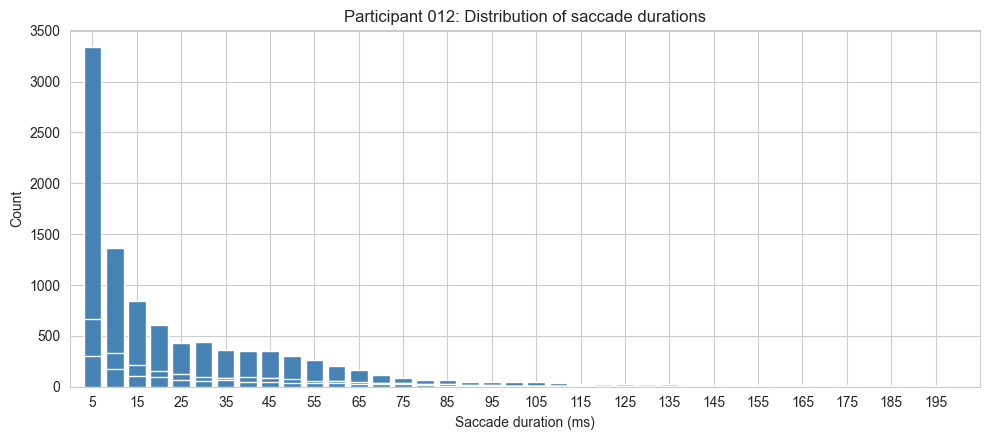

In [214]:
plt.figure(figsize=(10, 4.5))

plt.bar(
    duration_counts.index,
    duration_counts.values,
    width=4.0,
    color="steelblue",
    zorder=3
)

plt.grid(axis="y", zorder=0)

plt.xlabel("Saccade duration (ms)")
plt.ylabel("Count")
plt.title(f"Participant {participant_id}: Distribution of saccade durations")
plt.xticks(range(5, 205, 10))
plt.xlim(0, 205)
plt.tight_layout()
plt.show()


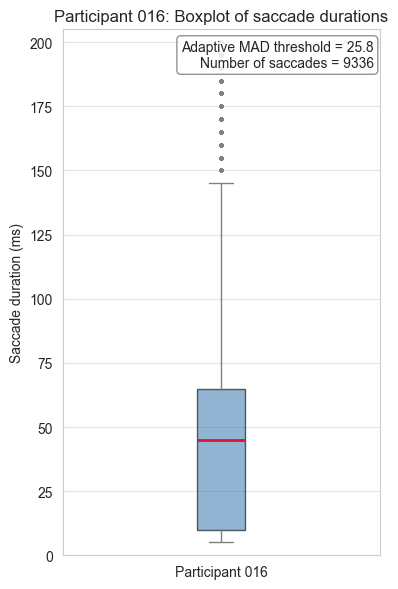

In [96]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(4, 6))

ax.boxplot(
    saccade_events_plot["duration_ms"].dropna(),
    patch_artist=True,
    boxprops=dict(facecolor="steelblue", alpha=0.6),
    medianprops=dict(color="crimson", linewidth=2),
    whiskerprops=dict(color="gray"),
    capprops=dict(color="gray"),
    flierprops=dict(
        marker="o",
        markerfacecolor="gray",
        markersize=3,
        alpha=0.4,
        markeredgecolor="none"
    )
)

info_text = (
    f"Adaptive MAD threshold = {global_mad_threshold:.1f}\n"
    f"Number of saccades = {total_saccades}"
)

ax.text(
    0.98, 0.98,
    info_text,
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=10,
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.85, edgecolor="gray")
)

ax.set_ylabel("Saccade duration (ms)")
ax.set_title(f"Participant {participant_id}: Boxplot of saccade durations")
ax.set_xticks([1])
ax.set_xticklabels([f"Participant {participant_id}"])
ax.set_ylim(0, 205)

ax.grid(axis="y", color="lightgray", alpha=0.6)
ax.grid(axis="x", visible=False)

plt.tight_layout()
plt.show()


In [30]:
participant_id = "012"
cond = 1
trial = 3

df_part = df[
    (df["participant_id"] == participant_id) &
    (df["condition_number"] == cond) &
    (df["trial_number"] == trial)
].copy()

df_part

,gaze_capture_time,raw_timestamp,relative_to_unix_epoch_timestamp,focus_distance,frame_number,stability,status,gaze_forward_x,gaze_forward_y,gaze_forward_z,...,clean_gaze_forward_x,clean_gaze_forward_y,clean_gaze_forward_z,segment_label,angular_velocity,mad_threshold,velocity_category,saccade_id,fixation_id,event_duration_ms
53863,1000002637168339100,1778654347487,767.6679,2.000000,514324,1.000000,Valid,0.391889,-0.138184,0.909576,...,0.391897,-0.138670,0.909498,C1_T3,NaN,35.720911,<NA>,<NA>,<NA>,NaN
53864,1000002637173342900,1778654347487,767.6679,2.000000,514325,0.958194,Valid,0.391897,-0.138670,0.909498,...,0.391910,-0.138877,0.909461,C1_T3,2.409520,35.720911,fixation,<NA>,1779,380.0532
53865,1000002637178343600,1778654347487,767.6679,2.000000,514326,0.956824,Valid,0.391923,-0.139084,0.909424,...,0.391923,-0.139084,0.909424,C1_T3,2.411014,35.720911,fixation,<NA>,1779,380.0532
53866,1000002637183344400,1778654347487,767.6679,2.000000,514327,0.963033,Valid,0.391958,-0.139534,0.909340,...,0.391958,-0.139534,0.909340,C1_T3,5.259896,35.720911,fixation,<NA>,1779,380.0532
53867,1000002637188348000,1778654347487,767.6679,2.000000,514328,0.960610,Valid,0.391993,-0.139895,0.909270,...,0.391992,-0.139895,0.909270,C1_T3,4.236852,35.720911,fixation,<NA>,1779,380.0532
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
72187,1000002735950725400,1778654446139,866.3199,0.808055,534073,0.000000,Valid,0.335577,-0.234332,0.912401,...,0.335469,-0.234334,0.912441,C1_T3,2.496071,35.720911,fixation,<NA>,2310,990.1386
72188,1000002735955727600,1778654446139,866.3199,0.810246,534074,0.000000,Valid,0.335342,-0.234679,0.912399,...,0.335323,-0.234658,0.912411,C1_T3,4.083972,35.720911,fixation,<NA>,2310,990.1386
72189,1000002735960728500,1778654446139,866.3199,0.814277,534075,0.000000,Valid,0.335177,-0.234671,0.912461,...,0.335286,-0.234684,0.912418,C1_T3,0.526229,35.720911,fixation,<NA>,2310,990.1386
72190,1000002735965730700,1778654446139,866.3199,0.813184,534076,0.000000,Valid,0.335078,-0.234769,0.912473,...,0.335228,-0.234724,0.912429,C1_T3,0.815269,35.720911,fixation,<NA>,2310,990.1386


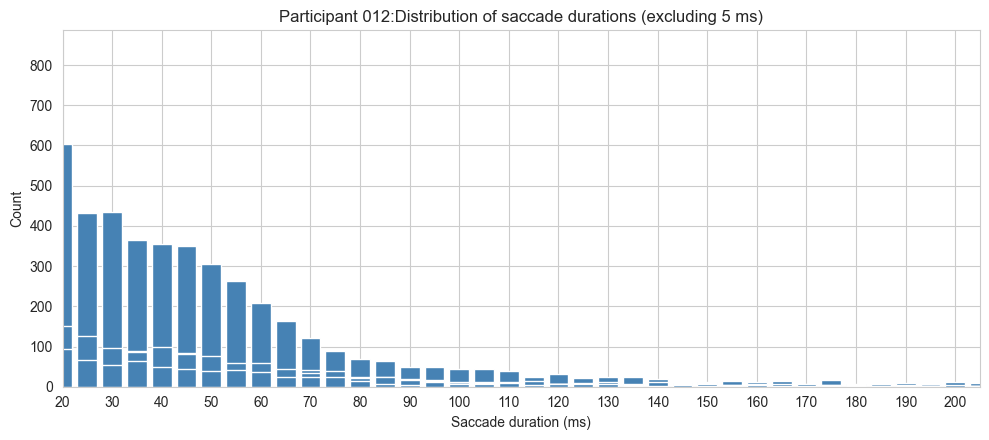

In [216]:
saccade_events_plot = saccade_events[saccade_events["duration_ms"] > 11].copy()

duration_counts = (
    saccade_events_plot["duration_ms"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(10, 4.5))
plt.bar(
    duration_counts.index,
    duration_counts.values,
    width=4.0,
    color="steelblue",
    edgecolor="white"
)

plt.xlabel("Saccade duration (ms)")
plt.ylabel("Count")
plt.title(f"Participant {participant_id}:Distribution of saccade durations (excluding 5 ms)")
plt.xticks(range(20, 205, 10))
plt.xlim(20, 205)
plt.tight_layout()
plt.show()


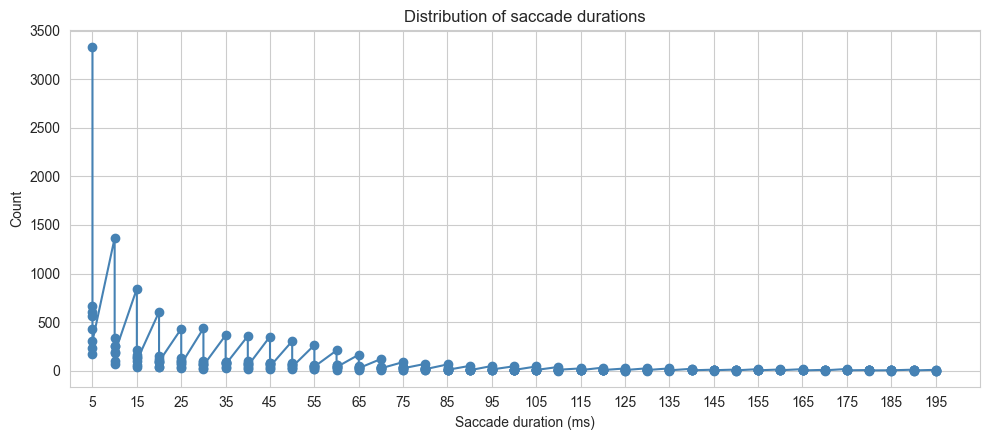

In [191]:
plt.figure(figsize=(10, 4.5))
plt.plot(duration_counts.index, duration_counts.values, marker="o", color="steelblue")
plt.xlabel("Saccade duration (ms)")
plt.ylabel("Count")
plt.title("Distribution of saccade durations")
plt.xticks(range(5, 205, 10))
plt.xlim(0, 205)
plt.tight_layout()
plt.show()


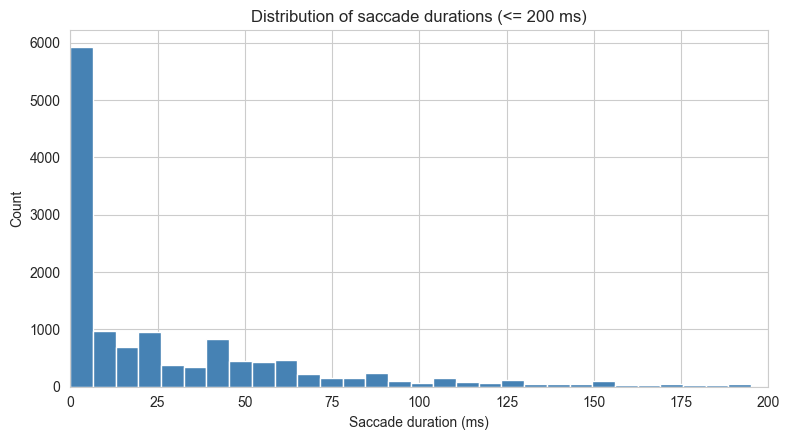

In [143]:
import matplotlib.pyplot as plt

# Keep only saccades up to 200 ms for plotting
saccade_events_200 = saccade_events[saccade_events["duration_ms"] <= 200].copy()

plt.figure(figsize=(8, 4.5))
plt.hist(
    saccade_events_200["duration_ms"].dropna(),
    bins=30,
    color="steelblue",
    edgecolor="white"
)

plt.xlabel("Saccade duration (ms)")
plt.ylabel("Count")
plt.title("Distribution of saccade durations (<= 200 ms)")
plt.xlim(0, 200)
plt.tight_layout()
plt.show()


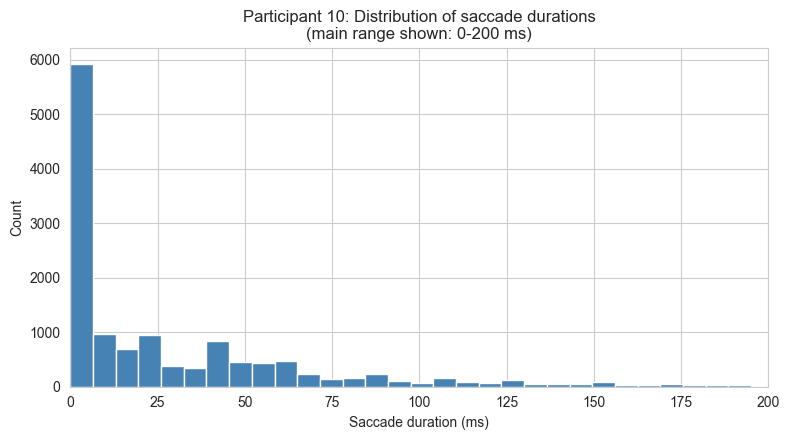

In [150]:
plt.figure(figsize=(8, 4.5))
plt.hist(
    saccade_events_200["duration_ms"].dropna(),
    bins=30,
    color="steelblue",
    edgecolor="white"
)

plt.xlabel("Saccade duration (ms)")
plt.ylabel("Count")
plt.title("Distribution of saccade durations\n(main range shown: 0-200 ms)")
plt.xlim(0, 200)
plt.tight_layout()
plt.show()


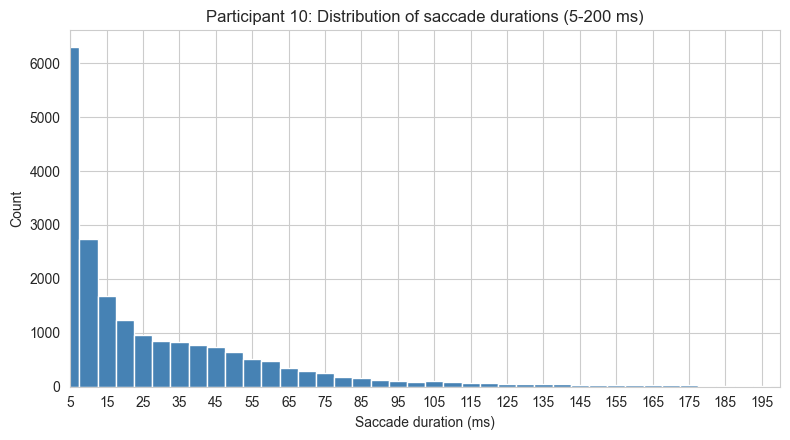

In [188]:
import numpy as np
import matplotlib.pyplot as plt

# Keep only durations from 5 to 200 ms
saccade_events_plot = saccade_events[
    (saccade_events["duration_ms"] >= 5) &
    (saccade_events["duration_ms"] <= 200)
].copy()

# 5 ms bins: 5, 10, 15, ..., 200
bins = np.arange(5, 205, 5)

plt.figure(figsize=(8, 4.5))
plt.hist(
    saccade_events_plot["duration_ms"].dropna(),
    bins=bins,
    color="steelblue",
    edgecolor="white",
    align="left"
)

plt.xlabel("Saccade duration (ms)")
plt.ylabel("Count")
plt.title("Participant 10: Distribution of saccade durations (5-200 ms)")
plt.xlim(5, 200)
plt.xticks(np.arange(5, 205, 10))
plt.tight_layout()
plt.show()


In [1]:
df

NameError: name 'df' is not defined